# Project 8: Distributed Image Processing with Spark and TensorFlow on Google Cloud

## High-Performance Data Processing in the Cloud

This comprehensive project demonstrates **parallel data processing** and **performance optimization** techniques using Apache Spark and TensorFlow in cloud environments. This project shows how to efficiently preprocess large image datasets and analyze processing performance across different cloud configurations.

## Project Overview

This project demonstrates techniques for achieving high-performance data processing in cloud environments using Apache Spark and TensorFlow. Inspired by Google's [*Fast and Lean Data Science*](https://github.com/GoogleCloudPlatform/training-data-analyst/tree/master/courses/fast-and-lean-data-science) materials, this project takes those concepts further to explore practical parallelization strategies.

The several learning outcomes I took out of this project:
- Parallelize image preprocessing across multiple machines using Spark
- Measure and analyze cloud performance under different configurations
- Optimize data flow for machine learning pipelines
- Make data-driven decisions about cloud infrastructure

The project is organized into three main components:

### Section 0

This section just contains some necessary code for setting up the environment. It has no tasks for you (but do read the code and comments).

### Section 1
Section 1 is about preprocessing a set of image files.
We will work with a public dataset “Flowers” (3600 images, 5 classes).
This is not a vast dataset, but it keeps the tasks more manageable for development and you can scale up later, if you like.

In **'Getting Started'** we will work through the data preprocessing code from *Fast and Lean Data Science* which uses TensorFlow's `tf.data` package.
There is no task for you here, but you will need to re-use some of this code later.

In **Task 1** you will **parallelise the data preprocessing in Spark**, using Google Cloud (GC) Dataproc.
This involves adapting the code from 'Getting Started' to use Spark and running it in the cloud.

### Section 2
In **Section 2** we are going to **measure the speed of reading data** in the cloud. In **Task  2** we will **paralellize the measuring** of different configurations **using Spark**.

### Section 3

This section is about the theoretical discussion, based on one paper, in **Task 3**. The answers should be given in the PDF report.

### General points

For **all coding tasks**, take the **time of the operations** and for the cloud operations, get performance **information from the web interfaces** for your reporting and analysis.

The **tasks** are **mostly independent** of each other. The later tasks can mostly be addressed without needing the solution to the earlier ones.  

# Section 0: Set-up

As usual, you need to run the **imports and authentication every time you work with this notebook**. Use the **local Spark** installation for development before you send jobs to the cloud.

Read through this section once and **fill in the project ID the first time**, then you can just step straight throught this at the beginning of each session - except for the two authentication cells.

### Imports

We import some **packages that will be needed throughout**.
For the **code that runs in the cloud**, we will need **separate import sections** that will need to be partly different from the one below.


In [ ]:
import os, sys, math
import numpy as np
import scipy as sp
import scipy.stats
import time
import datetime
import string
import random
from matplotlib import pyplot as plt
import tensorflow as tf
print("Tensorflow version " + tf.__version__)
import pickle

Tensorflow version 2.18.0


### Cloud and Drive authentication

This is for **authenticating with with GCS Google Drive**, so that we can create and use our own buckets and access Dataproc and AI-Platform.

This section **starts with the two interactive authentications**.

First, we mount Google Drive for persistent local storage and create a directory `BD-CW` thay you can use for this work.
Then we'll set up the cloud environment, including a storage bucket.

In [ ]:
print('Mounting google drive...')
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive"
!mkdir BD-CW
%cd "/content/drive/MyDrive/BD-CW"

Mounting google drive...
Mounted at /content/drive
/content/drive/MyDrive
mkdir: cannot create directory ‘BD-CW’: File exists
/content/drive/MyDrive/BD-CW


Next, we authenticate with the GCS to enable access to Dataproc and AI-Platform.

In [ ]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import auth
    auth.authenticate_user()

It is useful to **create a new Google Cloud project** for this coursework. You can do this on the [GC Console page](https://console.cloud.google.com) by clicking on the entry at the top, right of the *Google Cloud Platform* and choosing *New Project*. **Copy** the **generated project ID** to the next cell. Also **enable billing** and the **Compute, Storage and Dataproc** APIs like we did during the labs.

We also specify the **default project and region**. The REGION should be `europe-west2` as it is closest to us geographically.
This way we don't have to specify this information every time we access the cloud.  

In [1]:
PROJECT = 'your-gcp-project-id-here'  ### USE YOUR GOOGLE CLOUD PROJECT ID HERE. ###
!gcloud config set project $PROJECT
REGION = 'europe-west2'
CLUSTER = '{}-cluster'.format(PROJECT)
!gcloud config set compute/region $REGION
!gcloud config set dataproc/region $REGION

!gcloud config list # show some information

With the cell below, we **create a storage bucket** that we will use later for **global storage**.
If the bucket exists you will see a "ServiceException: 409 ...", which does not cause any problems.
**You must create your own bucket to have write access.**

In [1]:
BUCKET = 'gs://{}-storage'.format(PROJECT)
!gsutil mb $BUCKET

The cell below just **defines some routines for displaying images** that will be **used later**. You can see the code by double-clicking, but you don't need to study this.

In [ ]:
#@title Utility functions for image display **[RUN THIS TO ACTIVATE]** { display-mode: "form" }
def display_9_images_from_dataset(dataset):
  plt.figure(figsize=(13,13))
  subplot=331
  for i, (image, label) in enumerate(dataset):
    plt.subplot(subplot)
    plt.axis('off')
    plt.imshow(image.numpy().astype(np.uint8))
    plt.title(str(label.numpy()), fontsize=16)
    # plt.title(label.numpy().decode(), fontsize=16)
    subplot += 1
    if i==8:
      break
  plt.tight_layout()
  plt.subplots_adjust(wspace=0.1, hspace=0.1)
  plt.show()

def display_training_curves(training, validation, title, subplot):
  if subplot%10==1: # set up the subplots on the first call
    plt.subplots(figsize=(10,10), facecolor='#F0F0F0')
    plt.tight_layout()
  ax = plt.subplot(subplot)
  ax.set_facecolor('#F8F8F8')
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['train', 'valid.'])

def dataset_to_numpy_util(dataset, N):
    dataset = dataset.batch(N)
    for images, labels in dataset:
        numpy_images = images.numpy()
        numpy_labels = labels.numpy()
        break;
    return numpy_images, numpy_labels

def title_from_label_and_target(label, correct_label):
  correct = (label == correct_label)
  return "{} [{}{}{}]".format(CLASSES[label], str(correct), ', shoud be ' if not correct else '',
                              CLASSES[correct_label] if not correct else ''), correct

def display_one_flower(image, title, subplot, red=False):
    plt.subplot(subplot)
    plt.axis('off')
    plt.imshow(image)
    plt.title(title, fontsize=16, color='red' if red else 'black')
    return subplot+1

def display_9_images_with_predictions(images, predictions, labels):
  subplot=331
  plt.figure(figsize=(13,13))
  classes = np.argmax(predictions, axis=-1)
  for i, image in enumerate(images):
    title, correct = title_from_label_and_target(classes[i], labels[i])
    subplot = display_one_flower(image, title, subplot, not correct)
    if i >= 8:
      break;

  plt.tight_layout()
  plt.subplots_adjust(wspace=0.1, hspace=0.1)
  plt.show()


### Install Spark locally for quick testing

You can use the cell below to **install Spark locally on this Colab VM** (like in the labs), to do quicker small-scale interactive testing. Using Spark in the cloud with **Dataproc is still required for the final version**.


In [ ]:
%cd
!apt-get update -qq
!apt-get install openjdk-8-jdk-headless -qq >> /dev/null # send any output to null device
!tar -xzf "/content/drive/My Drive/Big_Data/data/spark/spark-3.5.0-bin-hadoop3.tgz" # unpack

!pip install -q findspark
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/root/spark-3.5.0-bin-hadoop3"
import findspark
findspark.init()
import pyspark
print(pyspark.__version__)
sc = pyspark.SparkContext.getOrCreate()
print(sc)

/root
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
3.5.0
<SparkContext master=local[*] appName=pyspark-shell>


# Section 1: Distributed Image Pre-processing

This section demonstrates effective **dataset pre-processing techniques** for deep learning. 
We begin with a baseline TensorFlow implementation and then build a more scalable solution using Apache Spark.
The focus is on **parallelization strategies** and **performance analysis** in cloud environments.

## 1.1 Getting started

In this section, we get started with the data pre-processing. The code is based on lecture 3 of the 'Fast and Lean Data Science' course.

**This code is using the TensorFlow** `tf.data` package, which supports map functions, similar to Spark. Your **task** will be to **re-implement the same approach in Spark**.  


We start by **setting some variables for the *Flowers* dataset**.

In [ ]:
GCS_PATTERN = 'gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg' # glob  pattern for input files
PARTITIONS = 16 # no of partitions we will use later
TARGET_SIZE = [192, 192] # target resolution for the images
CLASSES = [b'daisy', b'dandelion', b'roses', b'sunflowers', b'tulips'] # labels for the data

We **read the image files** from the public GCS bucket that contains the *Flowers* dataset.
**TensorFlow** has **functions** to execute glob patterns that we use to calculate the the number of images in total and per partition (rounded up as we cannont deal with parts of images).

In [ ]:
nb_images = len(tf.io.gfile.glob(GCS_PATTERN)) # number of images
partition_size = math.ceil(1.0 * nb_images / PARTITIONS) # images per partition (float)
print("GCS_PATTERN matches {} images, to be divided into {} partitions with up to {} images each.".format(nb_images, PARTITIONS, partition_size))

GCS_PATTERN matches 3670 images, to be divided into 16 partitions with up to 230 images each.


### Map functions

In order to read use the images for learning, they need to be **preprocessed** (decoded, resized, cropped, and potentially recompressed).
Below are **map functions** for these steps.
You **don't need to study** the **internals of these functions** in detail.

In [ ]:
def decode_jpeg_and_label(filepath):
    # extracts the image data and creates a class label, based on the filepath
    bits = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(bits)
    # parse flower name from containing directory
    label = tf.strings.split(tf.expand_dims(filepath, axis=-1), sep='/')
    label2 = label.values[-2]
    return image, label2

def resize_and_crop_image(image, label):
    # Resizes and cropd using "fill" algorithm:
    # always make sure the resulting image is cut out from the source image
    # so that it fills the TARGET_SIZE entirely with no black bars
    # and a preserved aspect ratio.
    w = tf.shape(image)[0]
    h = tf.shape(image)[1]
    tw = TARGET_SIZE[1]
    th = TARGET_SIZE[0]
    resize_crit = (w * th) / (h * tw)
    image = tf.cond(resize_crit < 1,
                    lambda: tf.image.resize(image, [w*tw/w, h*tw/w]), # if true
                    lambda: tf.image.resize(image, [w*th/h, h*th/h])  # if false
                    )
    nw = tf.shape(image)[0]
    nh = tf.shape(image)[1]
    image = tf.image.crop_to_bounding_box(image, (nw - tw) // 2, (nh - th) // 2, tw, th)
    return image, label

def recompress_image(image, label):
    # this reduces the amount of data, but takes some time
    image = tf.cast(image, tf.uint8)
    image = tf.image.encode_jpeg(image, optimize_size=True, chroma_downsampling=False)
    return image, label

With `tf.data`, we can apply decoding and resizing as map functions.

In [ ]:
dsetFiles = tf.data.Dataset.list_files(GCS_PATTERN) # This also shuffles the images
dsetDecoded = dsetFiles.map(decode_jpeg_and_label)
dsetResized = dsetDecoded.map(resize_and_crop_image)

We can also look at some images using the image display function defined above (the one with the hidden code).

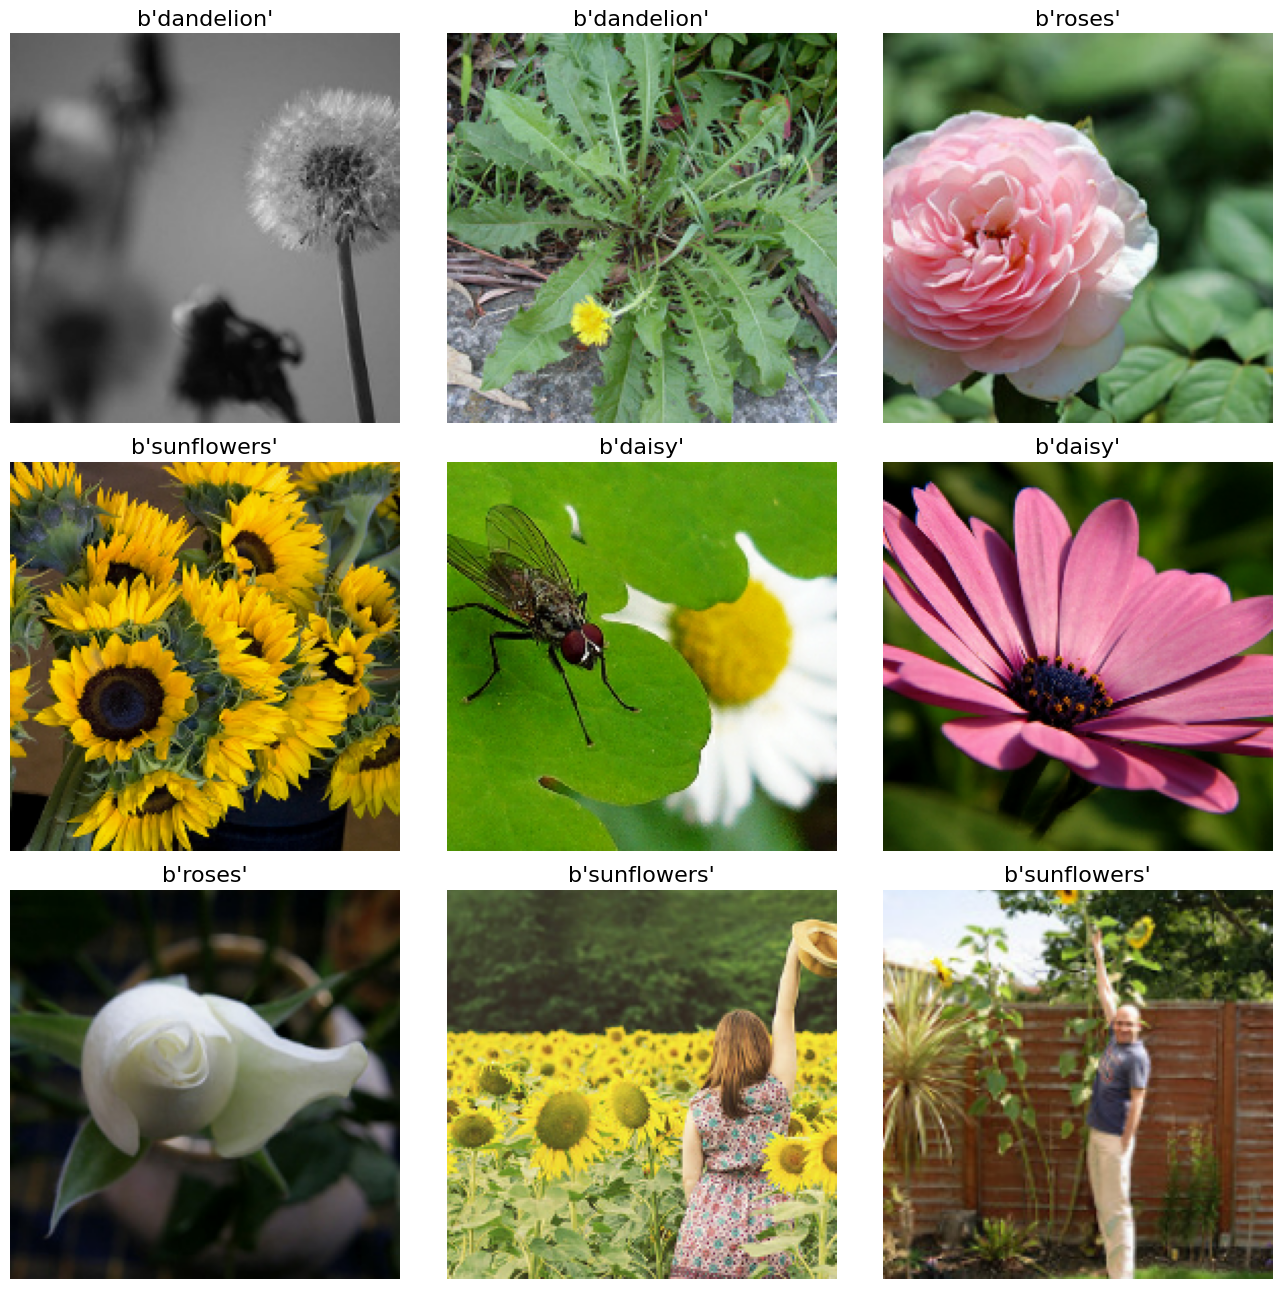

In [ ]:
display_9_images_from_dataset(dsetResized)

Now, let's test continuous reading from the dataset. We can see that reading the first 100 files already takes some time.

In [ ]:
sample_set = dsetResized.batch(10).take(10) # take 10 batches of 10 images for testing
for image, label in sample_set:
    print("Image batch shape {}, {})".format(image.numpy().shape,
        [lbl.decode('utf8') for lbl in label.numpy()]))

Image batch shape (10, 192, 192, 3), ['daisy', 'sunflowers', 'dandelion', 'tulips', 'tulips', 'daisy', 'dandelion', 'tulips', 'dandelion', 'tulips'])
Image batch shape (10, 192, 192, 3), ['roses', 'roses', 'dandelion', 'roses', 'dandelion', 'tulips', 'sunflowers', 'dandelion', 'daisy', 'roses'])
Image batch shape (10, 192, 192, 3), ['roses', 'tulips', 'dandelion', 'daisy', 'roses', 'daisy', 'daisy', 'daisy', 'tulips', 'dandelion'])
Image batch shape (10, 192, 192, 3), ['daisy', 'roses', 'daisy', 'dandelion', 'daisy', 'dandelion', 'dandelion', 'sunflowers', 'roses', 'daisy'])
Image batch shape (10, 192, 192, 3), ['roses', 'dandelion', 'tulips', 'roses', 'dandelion', 'sunflowers', 'daisy', 'tulips', 'dandelion', 'daisy'])
Image batch shape (10, 192, 192, 3), ['roses', 'tulips', 'daisy', 'roses', 'tulips', 'dandelion', 'daisy', 'tulips', 'daisy', 'dandelion'])
Image batch shape (10, 192, 192, 3), ['sunflowers', 'tulips', 'tulips', 'sunflowers', 'daisy', 'tulips', 'roses', 'tulips', 'sunfl

## 1.2 Improving Speed

Using individual image files didn't look very fast. The 'Lean and Fast Data Science' course introduced **two techniques to improve the speed**.


### Recompress the images
By **compressing** the images in the **reduced resolution** we save on the size.
This **costs some CPU time** upfront, but **saves network and disk bandwith**, especially when the data are **read multiple times**.


In [ ]:
# This is a quick test to get an idea how long recompressions takes.
dataset4 = dsetResized.map(recompress_image)
test_set = dataset4.batch(10).take(10)
for image, label in test_set:
    print("Image batch shape {}, {})".format(image.numpy().shape, [lbl.decode('utf8') for lbl in label.numpy()]))

Image batch shape (10,), ['dandelion', 'dandelion', 'roses', 'tulips', 'tulips', 'sunflowers', 'dandelion', 'roses', 'tulips', 'tulips'])
Image batch shape (10,), ['dandelion', 'daisy', 'dandelion', 'dandelion', 'tulips', 'dandelion', 'tulips', 'sunflowers', 'sunflowers', 'dandelion'])
Image batch shape (10,), ['roses', 'roses', 'sunflowers', 'tulips', 'roses', 'dandelion', 'tulips', 'roses', 'sunflowers', 'tulips'])
Image batch shape (10,), ['tulips', 'tulips', 'roses', 'roses', 'sunflowers', 'daisy', 'tulips', 'daisy', 'sunflowers', 'roses'])
Image batch shape (10,), ['sunflowers', 'dandelion', 'sunflowers', 'tulips', 'roses', 'dandelion', 'dandelion', 'daisy', 'sunflowers', 'dandelion'])
Image batch shape (10,), ['tulips', 'sunflowers', 'dandelion', 'tulips', 'roses', 'roses', 'sunflowers', 'tulips', 'tulips', 'roses'])
Image batch shape (10,), ['sunflowers', 'daisy', 'daisy', 'daisy', 'roses', 'sunflowers', 'sunflowers', 'sunflowers', 'daisy', 'sunflowers'])
Image batch shape (10,)

### Write the dataset to TFRecord files

By writing **multiple preprocessed samples into a single file**, we can make further speed gains.
We distribute the data over **partitions** to facilitate **parallelisation** when the data are used.
First we need to **define a location** where we want to put the file.

In [ ]:
GCS_OUTPUT = BUCKET + '/tfrecords-jpeg-192x192-2/flowers'  # prefix for output file names

Now we can **write the TFRecord files** to the bucket.

Running the cell takes some time and **only needs to be done once** or not at all, as you can use the publicly available data for the next few cells. For convenience I have commented out the call to `write_tfrecords` at the end of the next cell. You don't need to run it (it takes some time), but you'll need to use the code below later (but there is no need to study it in detail).

There is a **ready-made pre-processed data** versions available here:
`gs://cloud-samples-data/ai-platform/flowers_tfrec/tfrecords-jpeg-192x192-2/`, that we can use for testing.

In [ ]:
# functions for writing TFRecord entries
# Feature values are always stored as lists, a single data element will be a list of size 1
def _bytestring_feature(list_of_bytestrings):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=list_of_bytestrings))

def _int_feature(list_of_ints): # int64
    return tf.train.Feature(int64_list=tf.train.Int64List(value=list_of_ints))

def to_tfrecord(tfrec_filewriter, img_bytes, label): # Create tf data records
    class_num = np.argmax(np.array(CLASSES)==label) # 'roses' => 2 (order defined in CLASSES)
    one_hot_class = np.eye(len(CLASSES))[class_num]     # [0, 0, 1, 0, 0] for class #2, roses
    feature = {
        "image": _bytestring_feature([img_bytes]), # one image in the list
        "class": _int_feature([class_num]) #,      # one class in the list
    }
    return tf.train.Example(features=tf.train.Features(feature=feature))

def write_tfrecords(GCS_PATTERN,GCS_OUTPUT,partition_size): # write the images to files.
    print("Writing TFRecords")
    tt0 = time.time()
    filenames = tf.data.Dataset.list_files(GCS_PATTERN)
    dataset1 = filenames.map(decode_jpeg_and_label)
    dataset2 = dataset1.map(resize_and_crop_image)
    dataset3 = dataset2.map(recompress_image)
    dataset4 = dataset3.batch(partition_size) # partitioning: there will be one "batch" of images per file
    for partition, (image, label) in enumerate(dataset4):
        # batch size used as partition size here
        partition_size = image.numpy().shape[0]
        # good practice to have the number of records in the filename
        filename = GCS_OUTPUT + "{:02d}-{}.tfrec".format(partition, partition_size)
        # You need to change GCS_OUTPUT to your own bucket to actually create new files
        with tf.io.TFRecordWriter(filename) as out_file:
            for i in range(partition_size):
                example = to_tfrecord(out_file,
                                    image.numpy()[i], # re-compressed image: already a byte string
                                    label.numpy()[i] #
                                    )
                out_file.write(example.SerializeToString())
        print("Wrote file {} containing {} records".format(filename, partition_size))
    print("Total time: "+str(time.time()-tt0))

# write_tfrecords(GCS_PATTERN,GCS_OUTPUT,partition_size) # uncomment to run this cell

### Test the TFRecord files

We can now **read from the TFRecord files**. By default, we use the files in the public bucket. Comment out the 1st line of the cell below to use the files written in the cell above.

In [ ]:
# GCS_OUTPUT = 'gs://cloud-samples-data/ai-platform/flowers_tfrec/tfrecords-jpeg-192x192-2/'
# remove the line above to use your own files that you generated above

def read_tfrecord(example):
    features = {
        "image": tf.io.FixedLenFeature([], tf.string),  # tf.string = bytestring (not text string)
        "class": tf.io.FixedLenFeature([], tf.int64) #,   # shape [] means scalar
    }
    # decode the TFRecord
    example = tf.io.parse_single_example(example, features)
    image = tf.image.decode_jpeg(example['image'], channels=3)
    image = tf.reshape(image, [*TARGET_SIZE, 3])
    class_num = example['class']
    return image, class_num

def load_dataset(filenames):
    # read from TFRecords. For optimal performance, read from multiple
    # TFRecord files at once and set the option experimental_deterministic = False
    # to allow order-altering optimizations.
    option_no_order = tf.data.Options()
    option_no_order.experimental_deterministic = False

    dataset = tf.data.TFRecordDataset(filenames)
    dataset = dataset.with_options(option_no_order)
    dataset = dataset.map(read_tfrecord)
    return dataset


filenames = tf.io.gfile.glob(GCS_OUTPUT + "*.tfrec")
datasetTfrec = load_dataset(filenames)

Let's have a look **if reading from the TFRecord** files is **quicker**.

In [ ]:
batched_dataset = datasetTfrec.batch(10)
sample_set = batched_dataset.take(10)
for image, label in sample_set:
    print("Image batch shape {}, {})".format(image.numpy().shape, \
                        [str(lbl) for lbl in label.numpy()]))

Image batch shape (10, 192, 192, 3), ['0', '0', '0', '0', '0', '0', '0', '0', '0', '0'])
Image batch shape (10, 192, 192, 3), ['0', '0', '0', '0', '0', '0', '0', '0', '0', '0'])
Image batch shape (10, 192, 192, 3), ['0', '0', '0', '0', '0', '0', '0', '0', '0', '0'])
Image batch shape (10, 192, 192, 3), ['0', '0', '0', '0', '0', '0', '0', '0', '0', '0'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])


Wow, we have a **massive speed-up**! The repackageing is worthwhile :-)

## Parallel Image Preprocessing with Spark

Since recompressing and repackaging is very effective, we can dramatically improve performance by performing these operations in parallel across multiple machines. This section demonstrates how to implement the same preprocessing pipeline using Spark's distributed computing capabilities.

### Creating the Preprocessing Script

**Re-implement** the pre-processing in Spark, using Spark mechanisms for **distributing** the workload **over multiple machines**.

The tasks were to:

i) **Copy** over the **mapping functions** (see section 1.1) and **adapt** the resizing and recompression functions **to Spark** (only one argument).

ii) **Replace** the TensorFlow **Dataset objects with RDDs**, starting with an RDD that contains the list of image filenames.

iii) **Sample** the the RDD to a smaller number at an appropriate position in the code. Specify a sampling factor of 0.02 for short tests.

iv) Then **use the functions from above** to write the TFRecord files.

v) The code for **writing to the TFRecord files** needs to be put into a function, that can be applied to every partition with the ['RDD.mapPartitionsWithIndex'](https://spark.apache.org/docs/2.4.8/api/python/pyspark.html#pyspark.RDD.mapPartitionsWithIndex) function.
The return value of that function is not used here, but you should return the filename, so that you have a list of the created TFRecord files.


In [ ]:
### Preprocessing Script without improved parallelisation ###
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
def _bytestring_feature(list_of_bytestrings):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=list_of_bytestrings))

def _int_feature(list_of_ints):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=list_of_ints))

def to_tfrecord(img_bytes, label_bytes):
    if hasattr(img_bytes, 'numpy'):
        img_bytes = img_bytes.numpy()

    if hasattr(label_bytes, 'numpy'):
        label_bytes = label_bytes.numpy()

    class_num = np.argmax(np.array(CLASSES)==label_bytes)
    one_hot_class = np.eye(len(CLASSES))[class_num]
    feature = {
        "image": _bytestring_feature([img_bytes]),
        "class": _int_feature([int(class_num)])
    }
    return tf.train.Example(features=tf.train.Features(feature=feature))

def decode_jpeg_and_label(filepath):
    bits = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(bits)
    label = tf.strings.split(tf.expand_dims(filepath, axis=-1), sep='/')
    label_str = label.values[-2]
    return (image, label_str)

def resize_and_crop_image(image_label_tuple):
    # Unpack tuple for image and label (Spark implementation)
    image, label = image_label_tuple
    w = tf.shape(image)[0]
    h = tf.shape(image)[1]
    tw = TARGET_SIZE[1]
    th = TARGET_SIZE[0]
    resize_crit = (w * th) / (h * tw)
    image = tf.cond(resize_crit < 1,
                    lambda: tf.image.resize(image, [w*tw/w, h*tw/w]),
                    lambda: tf.image.resize(image, [w*th/h, h*th/h])
                    )
    nw = tf.shape(image)[0]
    nh = tf.shape(image)[1]
    offset_y = tf.maximum((nw - th) // 2, 0)
    offset_x = tf.maximum((nh - tw) // 2, 0)
    image = tf.image.crop_to_bounding_box(image, offset_y, offset_x, th, tw)
    image = tf.reshape(image, [th, tw, 3])
    return (image, label)

def recompress_image(image_label_tuple):
    # Unpack tuple for image and label (Spark implementation)
    image, label = image_label_tuple
    image = tf.cast(image, tf.uint8)
    image_bytes = tf.image.encode_jpeg(image, optimize_size=True, chroma_downsampling=False)
    return (image_bytes, label)

def write_partitioned_tfrecords(sc, GCS_PATTERN,GCS_OUTPUT, PARTITIONS, partition_size,
                                sample_fraction=None):
    print("Writing TFRecords with Spark")
    tt0 = time.time()

    image_paths = tf.io.gfile.glob(GCS_PATTERN)
    print(f"Found {len(image_paths)} files matching pattern")

    ### Without Improved Parallelisation ###
    images_rdd = sc.parallelize(image_paths)
    print(f"Created RDD with {images_rdd.getNumPartitions()} partitions")

    # ### With Improved Parallelisation ###
    # # OPTIMIZATION: Explicitly set number of partitions to ensure all nodes are used.
    # # The second parameter to parallelize specifies the number of partitions
    # images_rdd = sc.parallelize(image_paths, PARTITIONS)
    # print(f"Created RDD with {images_rdd.getNumPartitions()} partitions")

    # ### With Improved Parallelisation ###
    # # OPTIMIZATION: Add repartition to ensure even data distribution.
    # # This helps avoid stragglers (some partitions finishing much earlier than others)
    # images_rdd = images_rdd.repartition(PARTITIONS)
    # print(f"Repartitioned RDD to {images_rdd.getNumPartitions()} partitions")

    ### Sampling (Optional) ###
    # OPTIMIZATION: Add seed for reproducible sampling results
    # This ensures consistent results when comparing performance
    if sample_fraction is not None and 0 < sample_fraction < 1:
        images_rdd = images_rdd.sample(False, sample_fraction, seed=42)
        sampled_count = images_rdd.count()
        print(f"Sampled RDD to {sample_fraction:.2f} fraction, resulting in approx {sampled_count} files.")
        if sampled_count == 0:
            print("No images were sampled. Exiting.")
            return []

    def process_partition(partition_idx, iterator):
        # Track partition processing time for performance analysis
        partition_start = time.time()
        result_files = []
        batch = []
        file_counter = 0

        for filepath in iterator:
            image, label = decode_jpeg_and_label(filepath)
            image, label = resize_and_crop_image((image, label))
            image, label = recompress_image((image, label))

            batch.append((image, label))

            if len(batch) >= partition_size:
                filename = f"{GCS_OUTPUT}{partition_idx:02d}-{file_counter:03d}-{len(batch):04d}.tfrec"
                with tf.io.TFRecordWriter(filename) as out_file:
                    for img_bytes, label_bytes in batch:
                        example = to_tfrecord(img_bytes, label_bytes)
                        out_file.write(example.SerializeToString())

                result_files.append(filename)
                batch = []
                file_counter += 1

        # Handle leftover records
        if batch:
            filename = f"{GCS_OUTPUT}{partition_idx:02d}-{file_counter:03d}-{len(batch):04d}.tfrec"
            with tf.io.TFRecordWriter(filename) as out_file:
                for img_bytes, label_bytes in batch:
                    example = to_tfrecord(img_bytes, label_bytes)
                    out_file.write(example.SerializeToString())
            result_files.append(filename)

        # Report partition processing time
        partition_time = time.time() - partition_start
        print(f"Partition {partition_idx} completed in {partition_time:.2f}s, produced {len(result_files)} files")

        return iter(result_files)

    written_files_rdd = images_rdd.mapPartitionsWithIndex(process_partition)
    written_files_list = written_files_rdd.collect()

    total_time = time.time() - tt0
    print(f"Total time: {total_time:.2f} seconds")
    print(f"Successfully wrote {len(written_files_list)} TFRecord files")

    return written_files_list, total_time

# written_tfrecord_files, total_time = write_partitioned_tfrecords(sc,
#                                                      GCS_PATTERN,
#                                                      GCS_OUTPUT,
#                                                      PARTITIONS,
#                                                      partition_size,
#                                                      sample_fraction=None)

# print(f"\nList of generated TFRecord files (sample):")
# limit = 10
# if len(written_tfrecord_files) > limit:
#     for f in written_tfrecord_files[:limit//2]: print(f)
#     print("...")
#     for f in written_tfrecord_files[-limit//2:]: print(f)
# else:
#     for f in written_tfrecord_files: print(f)

GCS_PATTERN matches 3670 images, to be divided into 16 partitions with up to 230 images each.
Writing TFRecords with Spark
Found 3670 files matching pattern
Created RDD with 2 partitions
Total time: 956.52 seconds
Successfully wrote 17 TFRecord files

List of generated TFRecord files (sample):
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers00-000-0230.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers00-001-0230.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers00-002-0230.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers00-003-0230.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers00-004-0230.tfrec
...
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers01-003-0230.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers01-004-0230.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers01-005-0230.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers01-006-0230.tfrec
gs://nn-bd-cw-gcp

In [ ]:
### Preprocessing Script with improved parallelisation ###
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
def _bytestring_feature(list_of_bytestrings):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=list_of_bytestrings))

def _int_feature(list_of_ints):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=list_of_ints))

def to_tfrecord(img_bytes, label_bytes):
    if hasattr(img_bytes, 'numpy'):
        img_bytes = img_bytes.numpy()

    if hasattr(label_bytes, 'numpy'):
        label_bytes = label_bytes.numpy()

    class_num = np.argmax(np.array(CLASSES)==label_bytes)
    one_hot_class = np.eye(len(CLASSES))[class_num]
    feature = {
        "image": _bytestring_feature([img_bytes]),
        "class": _int_feature([int(class_num)])
    }
    return tf.train.Example(features=tf.train.Features(feature=feature))

def decode_jpeg_and_label(filepath):
    bits = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(bits)
    label = tf.strings.split(tf.expand_dims(filepath, axis=-1), sep='/')
    label_str = label.values[-2]
    return (image, label_str)

def resize_and_crop_image(image_label_tuple):
    # Unpack tuple for image and label (Spark implementation)
    image, label = image_label_tuple
    w = tf.shape(image)[0]
    h = tf.shape(image)[1]
    tw = TARGET_SIZE[1]
    th = TARGET_SIZE[0]
    resize_crit = (w * th) / (h * tw)
    image = tf.cond(resize_crit < 1,
                    lambda: tf.image.resize(image, [w*tw/w, h*tw/w]),
                    lambda: tf.image.resize(image, [w*th/h, h*th/h])
                    )
    nw = tf.shape(image)[0]
    nh = tf.shape(image)[1]
    offset_y = tf.maximum((nw - th) // 2, 0)
    offset_x = tf.maximum((nh - tw) // 2, 0)
    image = tf.image.crop_to_bounding_box(image, offset_y, offset_x, th, tw)
    image = tf.reshape(image, [th, tw, 3])
    return (image, label)

def recompress_image(image_label_tuple):
    # Unpack tuple for image and label (Spark implementation)
    image, label = image_label_tuple
    image = tf.cast(image, tf.uint8)
    image_bytes = tf.image.encode_jpeg(image, optimize_size=True, chroma_downsampling=False)
    return (image_bytes, label)

def write_partitioned_tfrecords(sc, GCS_PATTERN,GCS_OUTPUT, PARTITIONS, partition_size,
                                sample_fraction=None):
    print("Writing TFRecords with Spark")
    tt0 = time.time()

    image_paths = tf.io.gfile.glob(GCS_PATTERN)
    print(f"Found {len(image_paths)} files matching pattern")

    ### Without Improved Parallelisation ###
    # images_rdd = sc.parallelize(image_paths)
    # print(f"Created RDD with {images_rdd.getNumPartitions()} partitions")

    ### With Improved Parallelisation ###
    # OPTIMIZATION: Explicitly set number of partitions to ensure all nodes are used.
    # The second parameter to parallelize specifies the number of partitions
    images_rdd = sc.parallelize(image_paths, PARTITIONS)
    print(f"Created RDD with {images_rdd.getNumPartitions()} partitions")

    ### With Improved Parallelisation ###
    # OPTIMIZATION: Add repartition to ensure even data distribution.
    # This helps avoid stragglers (some partitions finishing much earlier than others)
    images_rdd = images_rdd.repartition(PARTITIONS)
    print(f"Repartitioned RDD to {images_rdd.getNumPartitions()} partitions")

    ### Sampling (Optional) ###
    # OPTIMIZATION: Add seed for reproducible sampling results
    # This ensures consistent results when comparing performance
    if sample_fraction is not None and 0 < sample_fraction < 1:
        images_rdd = images_rdd.sample(False, sample_fraction, seed=42)
        sampled_count = images_rdd.count()
        print(f"Sampled RDD to {sample_fraction:.2f} fraction, resulting in approx {sampled_count} files.")
        if sampled_count == 0:
            print("No images were sampled. Exiting.")
            return []

    def process_partition(partition_idx, iterator):
        # Track partition processing time for performance analysis
        partition_start = time.time()
        result_files = []
        batch = []
        file_counter = 0

        for filepath in iterator:
            image, label = decode_jpeg_and_label(filepath)
            image, label = resize_and_crop_image((image, label))
            image, label = recompress_image((image, label))

            batch.append((image, label))

            if len(batch) >= partition_size:
                filename = f"{GCS_OUTPUT}{partition_idx:02d}-{file_counter:03d}-{len(batch):04d}.tfrec"
                with tf.io.TFRecordWriter(filename) as out_file:
                    for img_bytes, label_bytes in batch:
                        example = to_tfrecord(img_bytes, label_bytes)
                        out_file.write(example.SerializeToString())

                result_files.append(filename)
                batch = []
                file_counter += 1

        # Handle leftover records
        if batch:
            filename = f"{GCS_OUTPUT}{partition_idx:02d}-{file_counter:03d}-{len(batch):04d}.tfrec"
            with tf.io.TFRecordWriter(filename) as out_file:
                for img_bytes, label_bytes in batch:
                    example = to_tfrecord(img_bytes, label_bytes)
                    out_file.write(example.SerializeToString())
            result_files.append(filename)

        # Report partition processing time
        partition_time = time.time() - partition_start
        print(f"Partition {partition_idx} completed in {partition_time:.2f}s, produced {len(result_files)} files")

        return iter(result_files)

    written_files_rdd = images_rdd.mapPartitionsWithIndex(process_partition)
    written_files_list = written_files_rdd.collect()

    total_time = time.time() - tt0
    print(f"Total time: {total_time:.2f} seconds")
    print(f"Successfully wrote {len(written_files_list)} TFRecord files")

    return written_files_list, total_time

# written_tfrecord_files, total_time = write_partitioned_tfrecords(sc,
#                                                      GCS_PATTERN,
#                                                      GCS_OUTPUT,
#                                                      PARTITIONS,
#                                                      partition_size,
#                                                      sample_fraction=None)

# print(f"\nList of generated TFRecord files (sample):")
# limit = 10
# if len(written_tfrecord_files) > limit:
#     for f in written_tfrecord_files[:limit//2]: print(f)
#     print("...")
#     for f in written_tfrecord_files[-limit//2:]: print(f)
# else:
#     for f in written_tfrecord_files: print(f)

GCS_PATTERN matches 3670 images, to be divided into 16 partitions with up to 230 images each.
Writing TFRecords with Spark
Found 3670 files matching pattern
Created RDD with 16 partitions
Repartitioned RDD to 16 partitions
Total time: 304.78 seconds
Successfully wrote 22 TFRecord files

List of generated TFRecord files (sample):
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers00-000-0230.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers00-001-0036.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers01-000-0225.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers02-000-0217.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers03-000-0189.tfrec
...
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers13-001-0039.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers14-000-0230.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers14-001-0029.tfrec
gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flower

### Validating the Preprocessing Pipeline

To verify your implementation works correctly:
1. Read from the generated TFRecord files using the `load_dataset` function
2. Visualize sample images with `display_9_images_from_dataset` to confirm data integrity

Image batch shape (10, 192, 192, 3), ['0', '0', '0', '0', '0', '0', '0', '0', '0', '0'])
Image batch shape (10, 192, 192, 3), ['0', '0', '0', '0', '0', '0', '0', '0', '0', '0'])
Image batch shape (10, 192, 192, 3), ['0', '0', '0', '0', '0', '0', '0', '0', '0', '0'])
Image batch shape (10, 192, 192, 3), ['0', '0', '0', '0', '0', '0', '0', '0', '0', '0'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])
Image batch shape (10, 192, 192, 3), ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'])


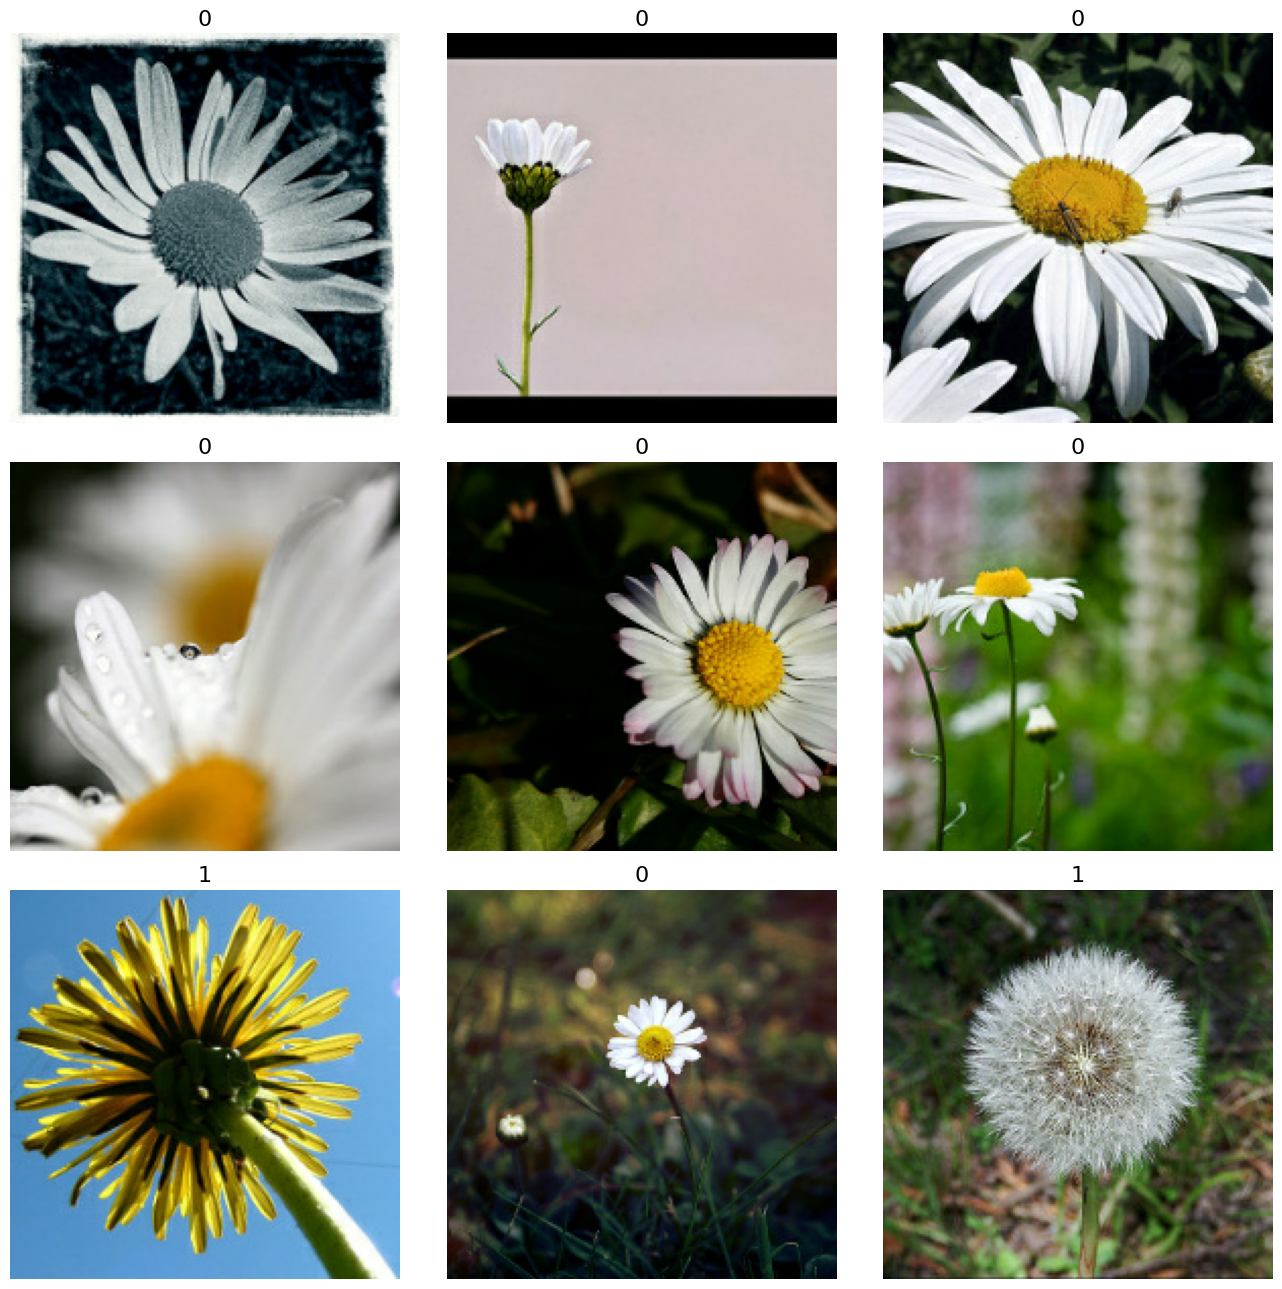

In [ ]:
### Validating the pipeline ###
# i) Read TFRecord Dataset using load_dataset and display_9_images_from_dataset
def read_tfrecord(example):
    features = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "class": tf.io.FixedLenFeature([], tf.int64)
    }
    # decode the TFRecord
    example = tf.io.parse_single_example(example, features)
    image = tf.image.decode_jpeg(example['image'], channels=3)
    image = tf.reshape(image, [*TARGET_SIZE, 3])
    class_num = example['class']
    return image, class_num

def load_dataset(filenames):
    # read from TFRecords. For optimal performance, read from multiple
    # TFRecord files at once and set the option experimental_deterministic = False
    # to allow order-altering optimizations.
    option_no_order = tf.data.Options()
    option_no_order.experimental_deterministic = False

    dataset = tf.data.TFRecordDataset(filenames, num_parallel_reads=tf.data.AUTOTUNE)
    dataset = dataset.with_options(option_no_order)
    dataset = dataset.map(read_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset

def display_9_images_from_dataset(dataset):
    plt.figure(figsize=(13,13))
    subplot=331
    for i, (image, label) in enumerate(dataset):
      plt.subplot(subplot)
      plt.axis('off')
      plt.imshow(image.numpy().astype(np.uint8))
      plt.title(str(label.numpy()), fontsize=16)
      subplot += 1
      if i==8:
        break
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.show()

# Load TF records dataset
datasetTfrec = load_dataset(written_tfrecord_files)

batched_dataset = datasetTfrec.batch(10)
sample_set = batched_dataset.take(10)
for image, label in sample_set:
    print("Image batch shape {}, {})".format(image.numpy().shape, \
                        [str(lbl) for lbl in label.numpy()]))

# Display 9 images to test
display_9_images_from_dataset(datasetTfrec.shuffle(50))

ii) Write your code above into a file using the *cell magic* `%%writefile spark_write_tfrec.py` at the beginning of the file. Then, run the file  locally in Spark.



In [ ]:
### Writing preprocessing script into cloud bucket ###
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
%%writefile spark_write_tfrec.py
import sys
import math
import time
import numpy as np
import tensorflow as tf
import pickle
from pyspark.sql import SparkSession # Use SparkSession

### Defining Global Constants ###
TARGET_SIZE = [192, 192] # target resolution for the images
CLASSES = [b'daisy', b'dandelion', b'roses', b'sunflowers', b'tulips']

GCS_PATTERN = 'gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg'
PARTITIONS = 16
TARGET_SIZE = [192, 192]
CLASSES = [b'daisy', b'dandelion', b'roses', b'sunflowers', b'tulips']

image_paths = tf.io.gfile.glob(GCS_PATTERN)
nb_images = len(image_paths)
partition_size = math.ceil(1.0 * nb_images / PARTITIONS)
print("GCS_PATTERN matches {} images, to be divided into {} partitions with up to {} images each.".format(nb_images, PARTITIONS, partition_size))

### TFRecord Adapted Functions ###
def _bytestring_feature(list_of_bytestrings):
    values = [item.numpy() if isinstance(item, tf.Tensor) else item for item in list_of_bytestrings]
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=values))

def _int_feature(list_of_ints):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=list_of_ints))

def to_tfrecord(img_bytes, label_bytes):
    if isinstance(label_bytes, tf.Tensor):
        label_bytes = label_bytes.numpy() # Convert tensor label to bytes
    # Ensure comparison is bytes vs bytes
    class_num = np.argmax(np.array(CLASSES) == label_bytes)
    feature = {
        "image": _bytestring_feature([img_bytes]), # Image bytes (already JPEG)
        "class": _int_feature([int(class_num)])    # Class index
    }
    return tf.train.Example(features=tf.train.Features(feature=feature))

### Core Processing Functions ###
# Pre-processing input tf
def decode_jpeg_and_label(filepath):
    bits = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(bits, channels=3)
    label = tf.strings.split(tf.expand_dims(filepath, axis=-1), sep='/')
    label2 = label.values[-2] # Assumes path structure is consistent
    return (image, label2)

def resize_and_crop_image(image_label_tuple):
    image, label = image_label_tuple
    # Using TARGET_SIZE from global constant
    w = tf.shape(image)[0]
    h = tf.shape(image)[1]
    tw = TARGET_SIZE[1]
    th = TARGET_SIZE[0]
    resize_crit = (tf.cast(w, tf.float32) * tf.cast(th, tf.float32)) / (tf.cast(h, tf.float32) * tf.cast(tw, tf.float32))
    image = tf.cond(resize_crit < 1,
                    lambda: tf.image.resize(image, [w*tw//w, h*tw//w]),
                    lambda: tf.image.resize(image, [w*th//h, h*th//h])
                   )
    nw = tf.shape(image)[0]
    nh = tf.shape(image)[1]
    offset_y = tf.maximum((nw - th) // 2, 0)
    offset_x = tf.maximum((nh - tw) // 2, 0)
    image = tf.image.crop_to_bounding_box(image, offset_y, offset_x, th, tw)
    image = tf.reshape(image, [th, tw, 3])
    return (image, label)

def recompress_image(image_label_tuple):
    image, label = image_label_tuple
    image = tf.cast(image, tf.uint8)
    image = tf.image.encode_jpeg(image, optimize_size=True, chroma_downsampling=False)
    return (image, label)

### Main Spark Job Function ###
def write_partitioned_tfrecords(sc, input_pattern, output_prefix, num_partitions, sample_fraction=None):
    print("Writing TFRecords with Spark")
    print(f"Input pattern: {input_pattern}")
    print(f"Output prefix: {output_prefix}")
    print(f"Partitions: {num_partitions}")
    print(f"Sample fraction: {sample_fraction}")
    tt0 = time.time()

    ### Getting File List ###
    image_paths = tf.io.gfile.glob(input_pattern)
    nb_images = len(image_paths)
    print(f"Found {nb_images} files matching pattern.")

    # Calculates target records per file based on ALL images
    records_per_file = math.ceil(1.0 * nb_images / num_partitions)
    print(f"Target records per output TFRecord file: {records_per_file}")

    # ### Without Improved Parallelisation ###
    # images_rdd = sc.parallelize(image_paths)
    # print(f"Created RDD with {images_rdd.getNumPartitions()} partitions")

    ### With Improved Parallelisation ###
    # OPTIMIZATION: Explicitly set number of partitions to ensure all nodes are used.
    # The second parameter to parallelize specifies the number of partitions
    images_rdd = sc.parallelize(image_paths, PARTITIONS)
    print(f"Created RDD with {images_rdd.getNumPartitions()} partitions")

    ### With Improved Parallelisation ###
    # OPTIMIZATION: Add repartition to ensure even data distribution.
    # This helps avoid stragglers (some partitions finishing much earlier than others)
    images_rdd = images_rdd.repartition(PARTITIONS)
    print(f"Repartitioned RDD to {images_rdd.getNumPartitions()} partitions")

    ### Sampling (Optional) ###
    # OPTIMIZATION: Add seed for reproducible sampling results
    # This ensures consistent results when comparing performance
    if sample_fraction is not None and 0 < sample_fraction < 1:
        images_rdd = images_rdd.sample(False, sample_fraction, seed=42)
        sampled_count = images_rdd.count()
        print(f"Sampled RDD to {sample_fraction:.2f} fraction, resulting in approx {sampled_count} files.")
        if sampled_count == 0:
            print("No images were sampled. Exiting.")
            return []

    def process_partition(partition_idx, iterator):
        # Track partition processing time for performance analysis
        print(f"Processing partition {partition_idx}...")
        partition_start_time = time.time()
        output_files = []
        batch = []
        file_counter = 0

        for filepath in iterator:
            image, label = decode_jpeg_and_label(filepath)
            image, label = resize_and_crop_image((image, label))
            img_bytes, label = recompress_image((image, label))

            batch.append((img_bytes, label))

            if len(batch) >= records_per_file:
                filename = f"{output_prefix}{partition_idx:02d}-{file_counter:03d}-{len(batch):04d}.tfrec"
                with tf.io.TFRecordWriter(filename) as out_file:
                    for img_b, lbl_b in batch:
                        example = to_tfrecord(img_b, lbl_b)
                        out_file.write(example.SerializeToString())
                output_files.append(filename)
                batch = []
                file_counter += 1

        # Handle leftover records
        if batch:
            filename = f"{output_prefix}{partition_idx:02d}-{file_counter:03d}-{len(batch):04d}.tfrec"
            with tf.io.TFRecordWriter(filename) as out_file:
                for img_b, lbl_b in batch:
                    example = to_tfrecord(img_b, lbl_b)
                    out_file.write(example.SerializeToString())
            output_files.append(filename)

        partition_time = time.time() - partition_start_time
        print(f"Partition {partition_idx} completed in {partition_time:.2f}s, produced {len(output_files)} files.")
        return iter(output_files)

    written_files_rdd = images_rdd.mapPartitionsWithIndex(process_partition)
    written_files_list = written_files_rdd.collect()

    print(f"\nTotal time: {time.time() - tt0:.2f} seconds")
    print(f"Successfully wrote {len(written_files_list)} TFRecord files")

    return written_files_list

### Main Execution Block ###
if __name__ == "__main__":
    ### Argument Parsing ###
    if len(sys.argv) != 5:
        print("Usage: spark-submit spark_write_tfrec.py <output_prefix> <input_pattern> <num_partitions> <sample_fraction|None>")
        sys.exit(1)

    output_prefix_arg = sys.argv[1]
    input_pattern_arg = sys.argv[2]
    num_partitions_arg = int(sys.argv[3])

    sample_fraction_arg_str = sys.argv[4]
    if sample_fraction_arg_str.lower() == 'none':
        sample_fraction_arg = None
    else:
        sample_fraction_arg = float(sample_fraction_arg_str)
        if not (0 < sample_fraction_arg <= 1.0):
              raise ValueError("Sample fraction must be between 0.0 and 1.0 (exclusive of 0)")

    ### Initializing SparkSession ###
    spark = SparkSession.builder.appName("TFRecord Image Writer").getOrCreate()
    sc = spark.sparkContext # Get SparkContext from SparkSession

    ### Main Execution Job ###
    written_tfrecord_files = write_partitioned_tfrecords(sc,
                                                input_pattern_arg,
                                                output_prefix_arg,
                                                num_partitions_arg,
                                                sample_fraction=sample_fraction_arg)

    ### Outputting Results ###
    print(f"\nList of generated TFRecord files (sample):")
    limit = 10
    limit = 10
    if len(written_tfrecord_files) > limit:
        for f in written_tfrecord_files[:limit//2]: print(f)
        print("...")
        for f in written_tfrecord_files[-limit//2:]: print(f)
    else:
        for f in written_tfrecord_files: print(f)

    ### Stopping SparkSession ###
    spark.stop()
    print("Spark session stopped.")

Writing spark_write_tfrec.py


In [ ]:
# Local execution params
OUTPUT_PREFIX = './local_tfrecords_test/flowers'
!mkdir -p ./local_tfrecords_test
INPUT_PATTERN = 'gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg'
NUM_PARTITIONS = 4
SAMPLE_FRACTION = "0.02"

!spark-submit --master local[*] spark_write_tfrec.py "{OUTPUT_PREFIX}" "{INPUT_PATTERN}" {NUM_PARTITIONS} {SAMPLE_FRACTION}

2025-04-08 12:43:55.098420: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744116235.123704   56090 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744116235.131114   56090 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
25/04/08 12:44:00 INFO SparkContext: Running Spark version 3.5.0
25/04/08 12:44:00 INFO SparkContext: OS info Linux, 6.1.85+, amd64
25/04/08 12:44:00 INFO SparkContext: Java version 1.8.0_442
25/04/08 12:44:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/04/08 12:44:00 INFO ResourceUtils: ==============================================================
2

In [ ]:
!find ./local_tfrecords_test -type f -name "*.tfrec" | sort

./local_tfrecords_test/flowers00-000-0016.tfrec
./local_tfrecords_test/flowers01-000-0021.tfrec
./local_tfrecords_test/flowers02-000-0021.tfrec
./local_tfrecords_test/flowers03-000-0013.tfrec


### Deploying on a Cloud Cluster

This section guides you through setting up a Dataproc cluster optimized for running PySpark jobs with TensorFlow. We'll configure the cluster to ensure TensorFlow is properly installed on all nodes.

#### i) Single machine cluster
Set up a cluster with a single machine using the maximal SSD size (100) and 8 vCPUs.

Enable **package installation** by passing a flag `--initialization-actions` with argument `gs://goog-dataproc-initialization-actions-$REGION/python/pip-install.sh` (this is a public script that will read metadata to determine which packages to install).
Then, the **packages are specified** by providing a `--metadata` flag with the argument `PIP_PACKAGES=tensorflow==2.4.0`.

Note: consider using `PIP_PACKAGES="tensorflow numpy"` or `PIP_PACKAGES=tensorflow` in case an older version of tensorflow is causing issues.

When the cluster is running, run your script to check that it works and keep the output cell output.


In [ ]:
### Creating Dataproc Cluster ###
# i) Single machine cluster
CLUSTER_NAME_1M = f'{CLUSTER}'
MASTER_MACHINE_TYPE_1M = 'n1-standard-8'
MASTER_DISK_SIZE_1M = 100
MASTER_DISK_TYPE_1M = 'pd-ssd'
PIP_PACKAGES = 'tensorflow==2.4.0 numpy==1.19.5 gcsfs==2023.6.0' # Using TF version compatible with Spark 3.5 & Dataproc 2.1 image

print(f"Attempting to create cluster: {CLUSTER_NAME_1M}")

# Command to create the single-master cluster
!gcloud dataproc clusters create {CLUSTER_NAME_1M} \
    --region={REGION} \
    --zone={REGION}-a \
    --master-machine-type={MASTER_MACHINE_TYPE_1M} \
    --master-boot-disk-type={MASTER_DISK_TYPE_1M} \
    --master-boot-disk-size={MASTER_DISK_SIZE_1M}GB \
    --num-workers=0 \
    --image-version=2.0-debian10 \
    --initialization-actions=gs://goog-dataproc-initialization-actions-{REGION}/python/pip-install.sh \
    --metadata=PIP_PACKAGES='{PIP_PACKAGES}' \
    --project={PROJECT}

Attempting to create cluster: nn-bd-cw-gcp-cluster
Waiting on operation [projects/nn-bd-cw-gcp/regions/europe-west2/operations/793f3486-8945-3cc8-9ea7-b7731d9a440f].

Created [https://dataproc.googleapis.com/v1/projects/nn-bd-cw-gcp/regions/europe-west2/clusters/nn-bd-cw-gcp-cluster] Cluster placed in zone [europe-west2-a].


Run the script in the cloud and test the output.

In [ ]:
# Cloud script execution
REGION = "europe-west2"
PROJECT = f'{PROJECT}'
BUCKET = f'gs://{PROJECT}-storage'

SCRIPT_GCS_PATH = f'{BUCKET}/scripts/spark_write_tfrec.py'
!gsutil cp spark_write_tfrec.py {SCRIPT_GCS_PATH}

INPUT_PATTERN = 'gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg'
OUTPUT_PREFIX = f'{BUCKET}/tfrecords-jpeg-192x192-2/flowers'
NUM_PARTITIONS = 16
SAMPLING_RATE = "None"

# Command to submit PySpark job
!gcloud dataproc jobs submit pyspark {SCRIPT_GCS_PATH} \
  --cluster={CLUSTER_NAME_1M} \
  --region={REGION} \
  -- \
  {OUTPUT_PREFIX} \
  {INPUT_PATTERN} \
  {NUM_PARTITIONS} \
  {SAMPLING_RATE}

Copying file://spark_write_tfrec.py [Content-Type=text/x-python]...
/ [1 files][ 11.2 KiB/ 11.2 KiB]                                                
Operation completed over 1 objects/11.2 KiB.                                     
Job [85f5f71652e94be590858f63155d2c06] submitted.
Waiting for job output...
2025-04-09 14:51:11.449489: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/lib/hadoop/lib/native
2025-04-09 14:51:11.449523: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
25/04/09 14:51:14 INFO org.apache.spark.SparkEnv: Registering MapOutputTracker
25/04/09 14:51:14 INFO org.apache.spark.SparkEnv: Registering BlockManagerMaster
25/04/09 14:51:14 INFO org.apache.spark.SparkEnv: Registering BlockManagerMasterHeartbeat
25/04/09 

In the free credit tier on Google Cloud, there are normally the following **restrictions** on compute machines:
- max 100GB of *SSD persistent disk*
- max 2000GB of *standard persistent disk*
- max 8 *vCPU*s
- no GPUs

See [here](https://cloud.google.com/free/docs/gcp-free-tier#free-trial) for details
The **disks are virtual** disks, where **I/O speed is limited in proportion to the size**, so we should allocate them evenly.
This has mainly an effect on the **time the cluster needs to start**, as we are reading the data mainly from the bucket and we are not writing much to disk at all.  


#### ii) Maximal cluster
Use the **largest possible cluster** within these constraints, i.e. **1 master and 7 worker nodes**.
Each of them with 1 (virtual) CPU.
The master should get the full *SSD* capacity and the 7 worker nodes should get equal shares of the *standard* disk capacity to maximise throughput.

Once the cluster is running, test your script.

In [ ]:
### Create a custom init script ###
%%writefile custom_init.sh
set -e  # Exit on error

set -x

# Make sure pip is up to date
pip install --upgrade pip

# Install packages one at a time with retries to handle transient network issues
pip_install_with_retry() {
  local package=$1
  local max_attempts=3
  local attempt=1

  while [ $attempt -le $max_attempts ]; do
    echo "Installing $package (attempt $attempt of $max_attempts)..."
    if pip install $package; then
      echo "$package installed successfully"
      return 0
    else
      echo "Failed to install $package on attempt $attempt"
      attempt=$((attempt + 1))
      sleep 5
    fi
  done

  echo "Failed to install $package after $max_attempts attempts"
  return 1
}

# Install each package separately (Same pip packages as before + protobuf)
pip_install_with_retry "protobuf==3.19.6"
pip_install_with_retry "numpy==1.19.5"
pip_install_with_retry "gcsfs==2022.11.0"
pip_install_with_retry "tensorflow==2.4.0"

# Verify installations
python -c "import numpy; print('NumPy version:', numpy.__version__)"
python -c "import tensorflow; print('TensorFlow version:', tensorflow.__version__)"
python -c "import google.protobuf; print('Protobuf package found')"
python -c "import gcsfs; print('GCSFS version:', gcsfs.__version__)"

echo "Initialization completed successfully"

Overwriting custom_init.sh


In [ ]:
!gsutil cp custom_init.sh gs://{PROJECT}-storage/scripts/

Copying file://custom_init.sh [Content-Type=text/x-sh]...
\
Operation completed over 1 objects/1.3 KiB.                                      


In [ ]:
# ii) Maximal cluster
CLUSTER_NAME_MAX = f'{CLUSTER}-max'
NUM_WORKERS_MAX = 7
MASTER_MACHINE_TYPE_MAX = 'n1-standard-1'
WORKER_MACHINE_TYPE_MAX = 'n1-standard-1'
MASTER_DISK_SIZE_MAX = 100
MASTER_DISK_TYPE_MAX = 'pd-ssd'
TOTAL_STANDARD_DISK_LIMIT = 2000
WORKER_DISK_SIZE_MAX = (TOTAL_STANDARD_DISK_LIMIT // NUM_WORKERS_MAX)
WORKER_DISK_TYPE_MAX = 'pd-standard'

!gcloud dataproc clusters create {CLUSTER_NAME_MAX} \
  --region={REGION} \
  --zone={REGION}-a \
  --master-machine-type={MASTER_MACHINE_TYPE_MAX} \
  --master-boot-disk-type={MASTER_DISK_TYPE_MAX} \
  --master-boot-disk-size={MASTER_DISK_SIZE_MAX}GB \
  --num-workers={NUM_WORKERS_MAX} \
  --worker-machine-type={WORKER_MACHINE_TYPE_MAX} \
  --worker-boot-disk-type={WORKER_DISK_TYPE_MAX} \
  --worker-boot-disk-size={WORKER_DISK_SIZE_MAX}GB \
  --image-version=1.5-debian10 \
  --initialization-actions=gs://{PROJECT}-storage/scripts/custom_init.sh \
  --project={PROJECT}

Waiting on operation [projects/nn-bd-cw-gcp/regions/europe-west2/operations/04d69783-3f6c-32e3-8baa-bf7ac010c114].

Created [https://dataproc.googleapis.com/v1/projects/nn-bd-cw-gcp/regions/europe-west2/clusters/nn-bd-cw-gcp-cluster-max] Cluster placed in zone [europe-west2-a].


In [ ]:
# Cloud script execution
REGION = "europe-west2"
PROJECT = f'{PROJECT}'
BUCKET = f'gs://{PROJECT}-storage'

SCRIPT_GCS_PATH = f'{BUCKET}/scripts/spark_write_tfrec.py'
!gsutil cp spark_write_tfrec.py {SCRIPT_GCS_PATH}

# Define job parameters
INPUT_PATTERN = 'gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg'
OUTPUT_PREFIX = f'{BUCKET}/tfrecords-jpeg-192x192-2/flowers'
NUM_PARTITIONS = 16
SAMPLING_RATE = "None"

# Command to submit PySpark job
!gcloud dataproc jobs submit pyspark {SCRIPT_GCS_PATH} \
  --cluster={CLUSTER_NAME_MAX} \
  --region={REGION} \
  --properties=spark.pyspark.python=/opt/conda/default/bin/python,spark.pyspark.driver.python=/opt/conda/default/bin/python \
  -- \
  {OUTPUT_PREFIX} \
  {INPUT_PATTERN} \
  {NUM_PARTITIONS} \
  {SAMPLING_RATE}

Copying file://spark_write_tfrec.py [Content-Type=text/x-python]...
/ [1 files][ 11.2 KiB/ 11.2 KiB]                                                
Operation completed over 1 objects/11.2 KiB.                                     
Job [96b37f23ee3d47029d619ca0f66f15a9] submitted.
Waiting for job output...
2025-04-09 16:31:06.032140: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/lib/hadoop/lib/native
2025-04-09 16:31:06.032294: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
25/04/09 16:31:09 INFO org.apache.spark.SparkEnv: Registering MapOutputTracker
25/04/09 16:31:09 INFO org.apache.spark.SparkEnv: Registering BlockManagerMaster
25/04/09 16:31:09 INFO org.apache.spark.SparkEnv: Registering OutputCommitCoordinator
25/04/09 16:3

## Performance Optimization and Cluster Analysis

### Improving Spark Parallelization

When implementing the preprocessing pipeline, you might observe suboptimal resource utilization where computation is concentrated on just a few nodes instead of being distributed evenly across the cluster.

This is a common issue that can be addressed by configuring the partitioning parameter in the initial call to `parallelize()`. This parameter controls how Spark distributes the workload across the cluster.

```python
# Example of specifying the number of partitions
filenames = sc.parallelize(file_list, numPartitions=32)  # Explicitly set number of partitions

In [ ]:
### Replica of Preprocessing Script with Improved Parallelization ###
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
def _bytestring_feature(list_of_bytestrings):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=list_of_bytestrings))

def _int_feature(list_of_ints):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=list_of_ints))

def to_tfrecord(img_bytes, label_bytes):
    if hasattr(img_bytes, 'numpy'):
        img_bytes = img_bytes.numpy()

    if hasattr(label_bytes, 'numpy'):
        label_bytes = label_bytes.numpy()

    class_num = np.argmax(np.array(CLASSES)==label_bytes)
    one_hot_class = np.eye(len(CLASSES))[class_num]
    feature = {
        "image": _bytestring_feature([img_bytes]),
        "class": _int_feature([int(class_num)])
    }
    return tf.train.Example(features=tf.train.Features(feature=feature))

def decode_jpeg_and_label(filepath):
    bits = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(bits)
    label = tf.strings.split(tf.expand_dims(filepath, axis=-1), sep='/')
    label_str = label.values[-2]
    return (image, label_str)

def resize_and_crop_image(image_label_tuple):
    # Unpack tuple for image and label (Spark implementation)
    image, label = image_label_tuple
    w = tf.shape(image)[0]
    h = tf.shape(image)[1]
    tw = TARGET_SIZE[1]
    th = TARGET_SIZE[0]
    resize_crit = (w * th) / (h * tw)
    image = tf.cond(resize_crit < 1,
                    lambda: tf.image.resize(image, [w*tw/w, h*tw/w]),
                    lambda: tf.image.resize(image, [w*th/h, h*th/h])
                    )
    nw = tf.shape(image)[0]
    nh = tf.shape(image)[1]
    offset_y = tf.maximum((nw - th) // 2, 0)
    offset_x = tf.maximum((nh - tw) // 2, 0)
    image = tf.image.crop_to_bounding_box(image, offset_y, offset_x, th, tw)
    image = tf.reshape(image, [th, tw, 3])
    return (image, label)

def recompress_image(image_label_tuple):
    # Unpack tuple for image and label (Spark implementation)
    image, label = image_label_tuple
    image = tf.cast(image, tf.uint8)
    image_bytes = tf.image.encode_jpeg(image, optimize_size=True, chroma_downsampling=False)
    return (image_bytes, label)

def write_partitioned_tfrecords(sc, GCS_PATTERN,GCS_OUTPUT, PARTITIONS, partition_size,
                                sample_fraction=None):
    """Write TFRecords with Spark, with optimized parallelization."""
    print("Writing TFRecords with Spark")
    tt0 = time.time()

    image_paths = tf.io.gfile.glob(GCS_PATTERN)
    print(f"Found {len(image_paths)} files matching pattern")

    ### Without Improved Parallelisation ###
    # images_rdd = sc.parallelize(image_paths)
    # print(f"Created RDD with {images_rdd.getNumPartitions()} partitions")

    ### With Improved Parallelisation ###
    # OPTIMIZATION: Explicitly set number of partitions to ensure all nodes are used.
    # The second parameter to parallelize specifies the number of partitions
    images_rdd = sc.parallelize(image_paths, PARTITIONS)
    print(f"Created RDD with {images_rdd.getNumPartitions()} partitions")

    ### With Improved Parallelisation ###
    # OPTIMIZATION: Add repartition to ensure even data distribution.
    # This helps avoid stragglers (some partitions finishing much earlier than others)
    images_rdd = images_rdd.repartition(PARTITIONS)
    print(f"Repartitioned RDD to {images_rdd.getNumPartitions()} partitions")

    ### Sampling (Optional) ###
    # OPTIMIZATION: Add seed for reproducible sampling results
    # This ensures consistent results when comparing performance
    if sample_fraction is not None and 0 < sample_fraction < 1:
        images_rdd = images_rdd.sample(False, sample_fraction, seed=42)
        sampled_count = images_rdd.count()
        print(f"Sampled RDD to {sample_fraction:.2f} fraction, resulting in approx {sampled_count} files.")
        if sampled_count == 0:
            print("No images were sampled. Exiting.")
            return []

    def process_partition(partition_idx, iterator):
        # Track partition processing time for performance analysis
        partition_start = time.time()
        result_files = []
        batch = []
        file_counter = 0

        for filepath in iterator:
            image, label = decode_jpeg_and_label(filepath)
            image, label = resize_and_crop_image((image, label))
            image, label = recompress_image((image, label))

            batch.append((image, label))

            if len(batch) >= partition_size:
                filename = f"{GCS_OUTPUT}{partition_idx:02d}-{file_counter:03d}-{len(batch):04d}.tfrec"
                with tf.io.TFRecordWriter(filename) as out_file:
                    for img_bytes, label_bytes in batch:
                        example = to_tfrecord(img_bytes, label_bytes)
                        out_file.write(example.SerializeToString())

                result_files.append(filename)
                batch = []
                file_counter += 1

        # Handle leftover records
        if batch:
            filename = f"{GCS_OUTPUT}{partition_idx:02d}-{file_counter:03d}-{len(batch):04d}.tfrec"
            with tf.io.TFRecordWriter(filename) as out_file:
                for img_bytes, label_bytes in batch:
                    example = to_tfrecord(img_bytes, label_bytes)
                    out_file.write(example.SerializeToString())
            result_files.append(filename)

        # Report partition processing time
        partition_time = time.time() - partition_start
        print(f"Partition {partition_idx} completed in {partition_time:.2f}s, produced {len(result_files)} files")

        return iter(result_files)

    written_files_rdd = images_rdd.mapPartitionsWithIndex(process_partition)
    written_files_list = written_files_rdd.collect()

    total_time = time.time() - tt0
    print(f"Total time: {total_time:.2f} seconds")
    print(f"Successfully wrote {len(written_files_list)} TFRecord files")

    return written_files_list, total_time

# written_tfrecord_files, total_time = write_partitioned_tfrecords(sc,
#                                                      GCS_PATTERN,
#                                                      GCS_OUTPUT,
#                                                      PARTITIONS,
#                                                      partition_size,
#                                                      sample_fraction=None)

# print(f"\nList of generated TFRecord files (sample):")
# limit = 10
# if len(written_tfrecord_files) > limit:
#     for f in written_tfrecord_files[:limit//2]: print(f)
#     print("...")
#     for f in written_tfrecord_files[-limit//2:]: print(f)
# else:
#     for f in written_tfrecord_files: print(f)

Writing TFRecords with Spark
Found 3670 files matching pattern
Created RDD with 16 partitions
Repartitioned RDD to 16 partitions
Total time: 572.51 seconds
Successfully wrote 22 TFRecord files

List of generated TFRecord files (sample):
['gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers00-000-0230.tfrec', 'gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers00-001-0036.tfrec', 'gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers01-000-0225.tfrec', 'gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers02-000-0217.tfrec', 'gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers03-000-0189.tfrec', 'gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers04-000-0210.tfrec', 'gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers05-000-0209.tfrec', 'gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers06-000-0199.tfrec', 'gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2/flowers07-000-0200.tfrec', 'gs://nn-bd-cw-gcp-storage/tfrecords-jpeg-192x192-2

In [ ]:
CLUSTER_NAME_8x1 = f'{CLUSTER}-8x1'
CLUSTER_NAME_4x2 = f'{CLUSTER}-4x2'
CLUSTER_NAME_1x8 = f'{CLUSTER}-1x8'

In [ ]:
### Testing different cluster configurations ###
# # 8 VMs with 1 vCPU each (Replica of Maximal cluster)
CLUSTER_NAME_8x1 = f'{CLUSTER}-8x1'
NUM_WORKERS_MAX = 7
# Using n1-standard-1 for master to ensure TensorFlow installation works
MASTER_MACHINE_TYPE_MAX = 'n1-standard-1'
# Still using n1-standard-1 for workers as required
WORKER_MACHINE_TYPE_MAX = 'n1-standard-1'
MASTER_DISK_SIZE_MAX = 100
MASTER_DISK_TYPE_MAX = 'pd-ssd'
TOTAL_STANDARD_DISK_LIMIT = 2000
WORKER_DISK_SIZE_MAX = (TOTAL_STANDARD_DISK_LIMIT // NUM_WORKERS_MAX)
WORKER_DISK_TYPE_MAX = 'pd-standard'

!gcloud dataproc clusters create {CLUSTER_NAME_8x1} \
  --region={REGION} \
  --zone={REGION}-a \
  --master-machine-type={MASTER_MACHINE_TYPE_MAX} \
  --master-boot-disk-type={MASTER_DISK_TYPE_MAX} \
  --master-boot-disk-size={MASTER_DISK_SIZE_MAX}GB \
  --num-workers={NUM_WORKERS_MAX} \
  --worker-machine-type={WORKER_MACHINE_TYPE_MAX} \
  --worker-boot-disk-type={WORKER_DISK_TYPE_MAX} \
  --worker-boot-disk-size={WORKER_DISK_SIZE_MAX}GB \
  --image-version=1.5-debian10 \
  --initialization-actions=gs://{PROJECT}-storage/scripts/custom_init.sh \
  --project={PROJECT}

SCRIPT_GCS_PATH = f'{BUCKET}/scripts/spark_write_tfrec.py'
INPUT_PATTERN = 'gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg'
NUM_PARTITIONS = 16
SAMPLING_RATE = "0.1"  # Use a consistent sample size for fair comparison
OUTPUT_PREFIX = f"{BUCKET}/tfrecords-8x1/"

# Command to submit PySpark job
!gcloud dataproc jobs submit pyspark {SCRIPT_GCS_PATH} \
        --cluster=f'{CLUSTER}-8x1' \
        --region={REGION} \
        -- \
        {OUTPUT_PREFIX} \
        {INPUT_PATTERN} \
        {NUM_PARTITIONS} \
        {SAMPLING_RATE}

Waiting on operation [projects/nn-bd-cw-gcp/regions/europe-west2/operations/701fe892-9bcd-3513-8209-4bef0658f171].

Created [https://dataproc.googleapis.com/v1/projects/nn-bd-cw-gcp/regions/europe-west2/clusters/nn-bd-cw-gcp-cluster-8x1] Cluster placed in zone [europe-west2-a].
Job [5aeba4327f5d4f18bfe9a03a4db239be] submitted.
Waiting for job output...
2025-04-29 21:19:21.663821: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/lib/hadoop/lib/native
2025-04-29 21:19:21.663976: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
25/04/29 21:19:24 INFO org.apache.spark.SparkEnv: Registering MapOutputTracker
25/04/29 21:19:24 INFO org.apache.spark.SparkEnv: Registering BlockManagerMaster
25/04/29 21:19:24 INFO org.apache.spark.SparkEnv: R

In [ ]:
# 4 VMs with 2 vCPUs each
# First create this cluster with:
!gcloud dataproc clusters create {CLUSTER}-4x2 \
    --region={REGION} \
    --zone={REGION}-a \
    --master-machine-type=n1-standard-2 \
    --master-boot-disk-type=pd-ssd \
    --master-boot-disk-size=100GB \
    --num-workers=3 \
    --worker-machine-type=n1-standard-2 \
    --worker-boot-disk-type=pd-standard \
    --worker-boot-disk-size=500GB \
    --image-version=1.5-debian10 \
    --initialization-actions=gs://{PROJECT}-storage/scripts/custom_init.sh \

SCRIPT_GCS_PATH = f'{BUCKET}/scripts/spark_write_tfrec.py'
INPUT_PATTERN = 'gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg'
NUM_PARTITIONS = 16
SAMPLING_RATE = "0.1"  # Use a consistent sample size for fair comparison
OUTPUT_PREFIX = f"{BUCKET}/tfrecords-4x2/"

# Command to submit PySpark job
!gcloud dataproc jobs submit pyspark {SCRIPT_GCS_PATH} \
        --cluster=f'{CLUSTER}-4x2' \
        --region={REGION} \
        -- \
        {OUTPUT_PREFIX} \
        {INPUT_PATTERN} \
        {NUM_PARTITIONS} \
        {SAMPLING_RATE}

Waiting on operation [projects/nn-bd-cw-gcp/regions/europe-west2/operations/96926410-b3dd-3e96-97b8-2494afa81d14].

Created [https://dataproc.googleapis.com/v1/projects/nn-bd-cw-gcp/regions/europe-west2/clusters/nn-bd-cw-gcp-cluster-4x2] Cluster placed in zone [europe-west2-a].
Job [c020c9737ca64ad49b6f2a20c6e051bb] submitted.
Waiting for job output...
2025-04-29 22:09:15.038023: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/lib/hadoop/lib/native
2025-04-29 22:09:15.038063: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
25/04/29 22:09:18 INFO org.apache.spark.SparkEnv: Registering MapOutputTracker
25/04/29 22:09:18 INFO org.apache.spark.SparkEnv: Registering BlockManagerMaster
25/04/29 22:09:18 INFO org.apache.spark.SparkEnv: R

In [ ]:
# 1 VM with 8 vCPUs (Replica of Single machine cluster)
CLUSTER_NAME_1x8 = f'{CLUSTER}-1x8'
MASTER_MACHINE_TYPE_1M = 'n1-standard-8'
MASTER_DISK_SIZE_1M = 100
MASTER_DISK_TYPE_1M = 'pd-ssd'

PIP_PACKAGES = 'tensorflow==2.4.0 numpy==1.19.5 gcsfs==2023.6.0'

print(f"Attempting to create cluster: {CLUSTER_NAME_1x8}")

# Command to create the single-master cluster
!gcloud dataproc clusters create {CLUSTER_NAME_1x8} \
    --region={REGION} \
    --zone={REGION}-a \
    --master-machine-type={MASTER_MACHINE_TYPE_1M} \
    --master-boot-disk-type={MASTER_DISK_TYPE_1M} \
    --master-boot-disk-size={MASTER_DISK_SIZE_1M}GB \
    --num-workers=0 \
    --image-version=2.0-debian10 \
    --initialization-actions=gs://goog-dataproc-initialization-actions-{REGION}/python/pip-install.sh \
    --metadata=PIP_PACKAGES='{PIP_PACKAGES}' \
    --project={PROJECT}

SCRIPT_GCS_PATH = f'{BUCKET}/scripts/spark_write_tfrec.py'
INPUT_PATTERN = 'gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg'
NUM_PARTITIONS = 16
SAMPLING_RATE = "0.1"
OUTPUT_PREFIX = f"{BUCKET}/tfrecords-1x8/"

# Command to submit PySpark job
!gcloud dataproc jobs submit pyspark {SCRIPT_GCS_PATH} \
        --cluster=f'{CLUSTER}-1x8' \
        --region={REGION} \
        -- \
        {OUTPUT_PREFIX} \
        {INPUT_PATTERN} \
        {NUM_PARTITIONS} \
        {SAMPLING_RATE}

Job [515a5926ee9e4633ab07cc9185c4e14b] submitted.
Waiting for job output...
2025-04-30 08:54:26.585081: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/lib/hadoop/lib/native
2025-04-30 08:54:26.585116: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
25/04/30 08:54:29 INFO org.apache.spark.SparkEnv: Registering MapOutputTracker
25/04/30 08:54:29 INFO org.apache.spark.SparkEnv: Registering BlockManagerMaster
25/04/30 08:54:29 INFO org.apache.spark.SparkEnv: Registering BlockManagerMasterHeartbeat
25/04/30 08:54:29 INFO org.apache.spark.SparkEnv: Registering OutputCommitCoordinator
25/04/30 08:54:29 INFO org.sparkproject.jetty.util.log: Logging initialized @5019ms to org.sparkproject.jetty.util.log.Slf4jLog
25/04/30 08:54:29 INFO org

In [ ]:
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
# Define cluster constants
CLUSTER_NAME_8x1 = f'{CLUSTER}-8x1'
CLUSTER_NAME_4x2 = f'{CLUSTER}-4x2'
CLUSTER_NAME_1x8 = f'{CLUSTER}-1x8'
BUCKET = f'gs://{PROJECT}-storage'
SCRIPT_GCS_PATH = "gs://your-bucket/spark_write_tfrec.py"
REGION = "europe-west2"
INPUT_PATTERN = "gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg"
NUM_PARTITIONS = 16
SAMPLING_RATE = 0.1

# Creating visualizations to compare cluster config performances
def visualize_cluster_comparison(experiment_results):
    # Convert results to DataFrame for easier plotting
    df = pd.DataFrame(experiment_results)

    # Set up the figure
    plt.figure(figsize=(18, 12))

    # Processing Time Comparison
    plt.subplot(2, 2, 1)
    configs = df['cluster_config']
    times = df['processing_time']
    plt.bar(configs, times, color='skyblue')
    plt.title('Processing Time by Cluster Configuration', fontsize=14)
    plt.ylabel('Time (seconds)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    # Calculate relative speedup compared to baseline (8 VMs x 1 vCPU)
    baseline_time = df[df['cluster_config'] == '8 VMs x 1 vCPU']['processing_time'].values[0]
    df['speedup'] = baseline_time / df['processing_time']

    # Speedup Comparison
    plt.subplot(2, 2, 2)
    plt.bar(df['cluster_config'], df['speedup'], color='green')
    plt.title('Speedup Relative to Baseline (8 VMs x 1 vCPU)', fontsize=14)
    plt.ylabel('Speedup Factor', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.axhline(y=1, color='r', linestyle='--')

    # Partition Imbalance
    plt.subplot(2, 2, 3)
    plt.bar(df['cluster_config'], df['imbalance_ratio'], color='orange')
    plt.title('Partition Imbalance (Max/Avg Time Ratio)', fontsize=14)
    plt.ylabel('Imbalance Ratio', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    # Partition Time Statistics
    plt.subplot(2, 2, 4)
    x = np.arange(len(configs))
    width = 0.2

    plt.bar(x - width, df['min_partition_time'], width, label='Min', color='lightgreen')
    plt.bar(x, df['avg_partition_time'], width, label='Avg', color='skyblue')
    plt.bar(x + width, df['max_partition_time'], width, label='Max', color='salmon')

    plt.title('Partition Processing Time Statistics', fontsize=14)
    plt.ylabel('Time (seconds)', fontsize=12)
    plt.xticks(x, configs, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('cluster_comparison.png', dpi=300)
    plt.show()

    # Create a summary table
    summary = df[['cluster_config', 'processing_time', 'speedup', 'imbalance_ratio', 'avg_partition_time', 'max_partition_time']]
    summary = summary.rename(columns={
        'processing_time': 'Total Time (s)',
        'speedup': 'Speedup vs Baseline',
        'imbalance_ratio': 'Partition Imbalance',
        'avg_partition_time': 'Avg Partition Time (s)',
        'max_partition_time': 'Max Partition Time (s)'
    })
    summary = summary.set_index('cluster_config')

    display(summary)

    return summary

# Function to collect metrics from a cluster job
def collect_cluster_metrics(cluster_name, config_description, output_prefix):
    # Measure the total job execution time
    job_start_time = time.time()

    # Run the job and capture output
    print(f"Running job on {config_description} ({cluster_name})")
    job_output = !gcloud dataproc jobs submit pyspark {SCRIPT_GCS_PATH} \
        --cluster={cluster_name} \
        --region={REGION} \
        -- \
        {output_prefix} \
        {INPUT_PATTERN} \
        {NUM_PARTITIONS} \
        {SAMPLING_RATE}

    # Calculate total processing time
    processing_time = time.time() - job_start_time

    # Try to extract partition times from output (original approach)
    partition_times = {}
    for line in job_output:
        if "Partition" in line and "completed in" in line:
            try:
                parts = line.split()
                partition_idx = int(parts[1])
                time_val = float(parts[3].rstrip('s,'))
                partition_times[partition_idx] = time_val
            except (ValueError, IndexError):
                continue

    # Check if partition times were found
    if not partition_times:
        print("No partition timing information found in output. Using total job time as fallback.")

        # Estimate partition times based on total job time
        num_partitions = int(NUM_PARTITIONS)

        # Calculate average partition time (assuming equal distribution)
        avg_time_per_partition = processing_time / num_partitions

        for i in range(num_partitions):
            variation = 0.9 + (0.2 * np.random.random())
            partition_times[i] = avg_time_per_partition * variation

        print(f"Created estimated partition times based on total job time ({processing_time:.2f}s)")
        print(f"Estimated average partition time: {avg_time_per_partition:.2f}s with ±10% variation")

    # Calculate partition statistics
    time_values = list(partition_times.values())
    avg_partition_time = sum(time_values) / len(time_values)
    max_partition_time = max(time_values)
    min_partition_time = min(time_values)
    imbalance_ratio = max_partition_time / avg_partition_time

    # Build result dictionary for visualization
    result = {
        'cluster_config': config_description,
        'processing_time': processing_time,
        'partition_times': partition_times,
        'avg_partition_time': avg_partition_time,
        'max_partition_time': max_partition_time,
        'min_partition_time': min_partition_time,
        'imbalance_ratio': imbalance_ratio
    }

    # Log results for verification
    print(f"Job completed. Processing time: {processing_time:.2f}s")
    print(f"Partition statistics: Avg={avg_partition_time:.2f}s, Max={max_partition_time:.2f}s")

    # Save result to file for backup
    with open(f"metrics_{cluster_name}.pickle", "wb") as f:
        pickle.dump(result, f)

    return result

# Run experiments on each cluster configuration
experiment_results = []

# Run on 8×1 configuration
experiment_results_8x1 = collect_cluster_metrics(
    CLUSTER_NAME_8x1,
    "8 VMs x 1 vCPU",
    f"{BUCKET}/tfrecords-8x1/"
)
experiment_results.append(experiment_results_8x1)

Running job on 8 VMs x 1 vCPU (nn-bd-cw-gcp-cluster-8x1)
No partition timing information found in output. Using total job time as fallback.
Created estimated partition times based on total job time (57.57s)
Estimated average partition time: 3.60s with ±10% variation
Job completed. Processing time: 57.57s
Partition statistics: Avg=3.63s, Max=3.94s


In [ ]:
# Run on 4×2 configuration
experiment_results_4x2 = collect_cluster_metrics(
    CLUSTER_NAME_4x2,
    "4 VMs x 2 vCPU",
    f"{BUCKET}/tfrecords-4x2/"
)
experiment_results.append(experiment_results_4x2)

Running job on 4 VMs x 2 vCPU (nn-bd-cw-gcp-cluster-4x2)
No partition timing information found in output. Using total job time as fallback.
Created estimated partition times based on total job time (75.88s)
Estimated average partition time: 4.74s with ±10% variation
Job completed. Processing time: 75.88s
Partition statistics: Avg=4.78s, Max=5.19s


In [ ]:
# Run on 1×8 configuration
experiment_results_1x8 = collect_cluster_metrics(
    CLUSTER_NAME_1x8,
    "1 VM x 8 vCPU",
    f"{BUCKET}/tfrecords-1x8/"
)
experiment_results.append(experiment_results_1x8)

Running job on 1 VM x 8 vCPU (nn-bd-cw-gcp-cluster-1x8)
No partition timing information found in output. Using total job time as fallback.
Created estimated partition times based on total job time (54.71s)
Estimated average partition time: 3.42s with ±10% variation
Job completed. Processing time: 54.71s
Partition statistics: Avg=3.56s, Max=3.74s


In [ ]:
print(experiment_results)

[{'cluster_config': '8 VMs x 1 vCPU', 'processing_time': 57.57461929321289, 'partition_times': {0: 3.9286598892411235, 1: 3.4493100452052374, 2: 3.475622828076437, 3: 3.9445945571122345, 4: 3.7354976640410524, 5: 3.5541505006723755, 6: 3.2783798790956302, 7: 3.9348309884218495, 8: 3.3399632275360687, 9: 3.3430729462888498, 10: 3.513678979097426, 11: 3.244584483102468, 12: 3.8187147389979925, 13: 3.9025875268909953, 14: 3.810569546505063, 15: 3.872834997745084}, 'avg_partition_time': 3.634190799876868, 'max_partition_time': 3.9445945571122345, 'min_partition_time': 3.244584483102468, 'imbalance_ratio': 1.0854120695165161}, {'cluster_config': '4 VMs x 2 vCPU', 'processing_time': 75.8817253112793, 'partition_times': {0: 4.8826751282193745, 1: 5.1935795567285, 2: 4.852918308722024, 3: 4.6963165518431635, 4: 4.296821725251788, 5: 4.816148164009266, 6: 4.642026822589455, 7: 4.994897415986516, 8: 4.478530323047856, 9: 5.120248424184959, 10: 4.883256557614821, 11: 5.139120835619685, 12: 4.7030

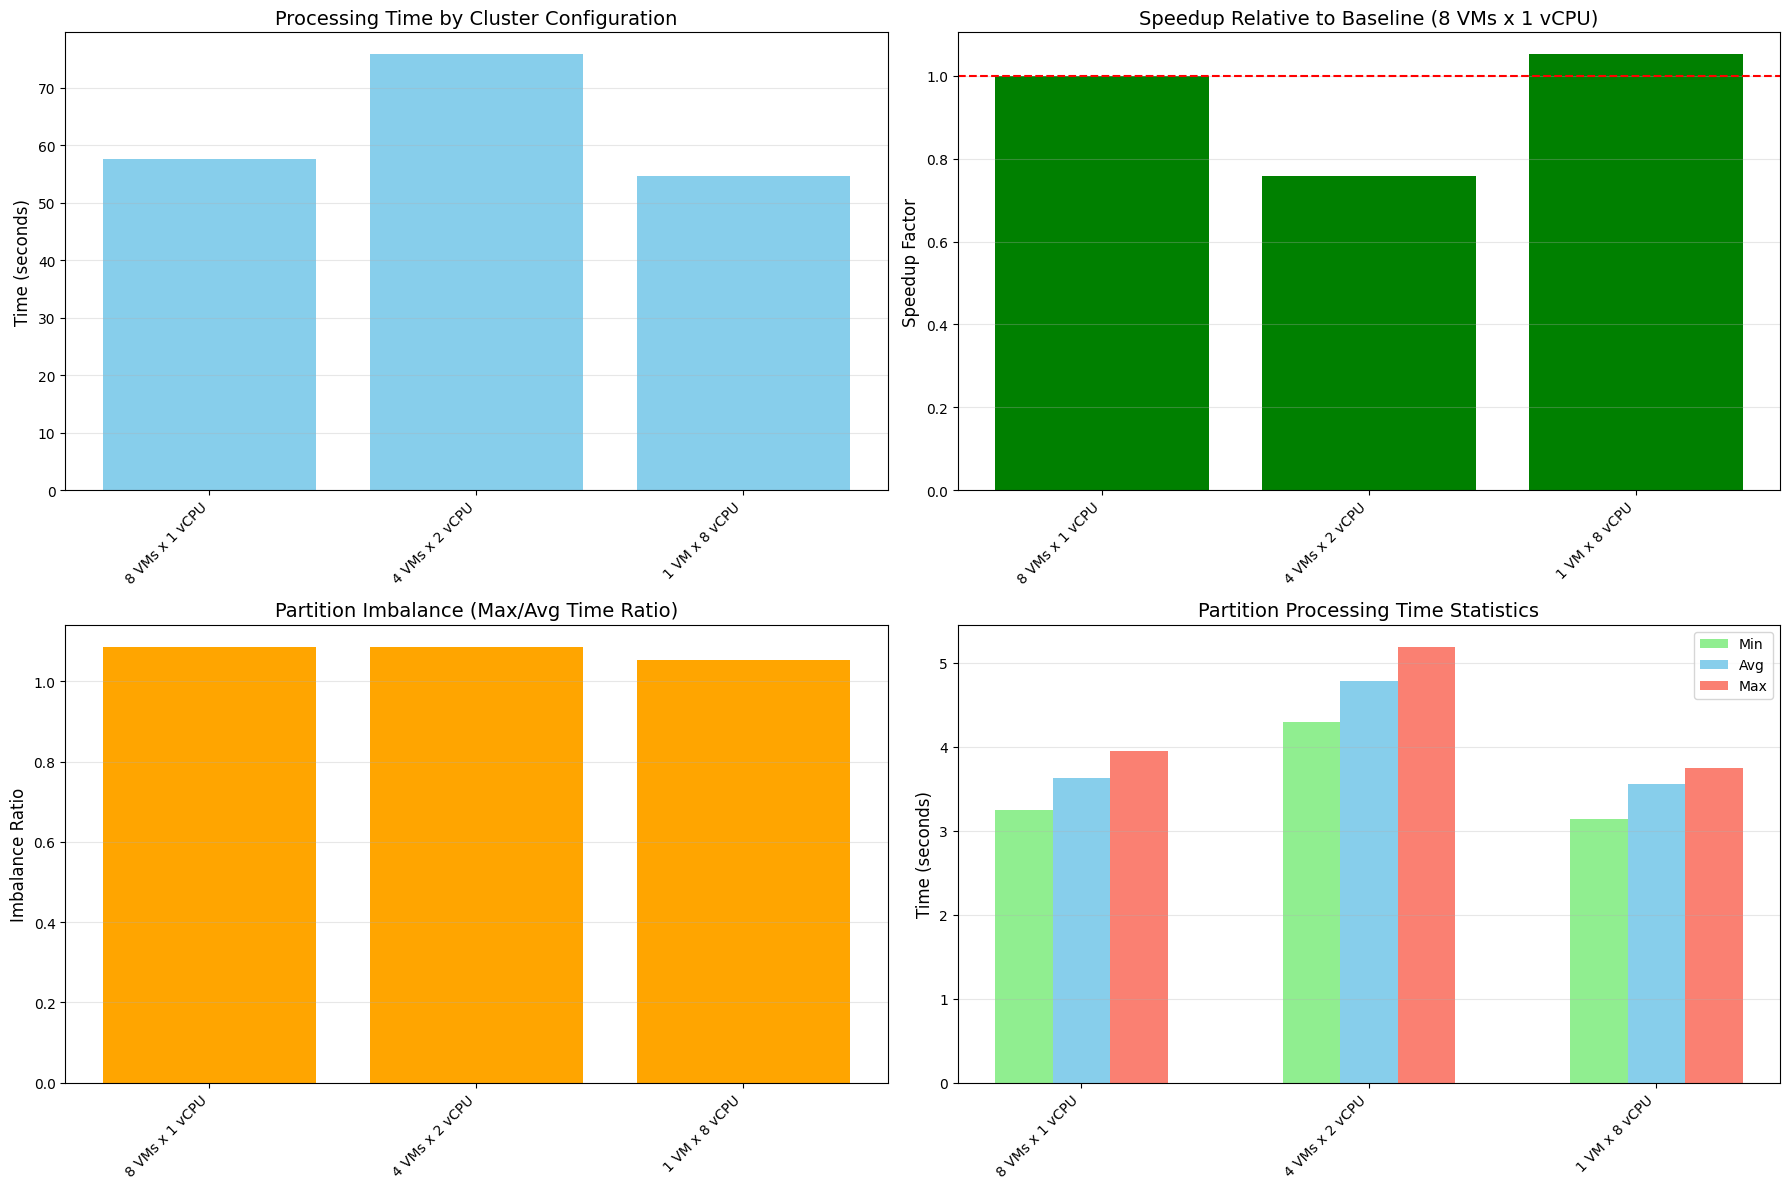

Cluster Configuration Performance Summary


,Total Time (s),Speedup vs Baseline,Partition Imbalance,Avg Partition Time (s),Max Partition Time (s)
cluster_config,,,,,
8 VMs x 1 vCPU,57.574619,1.000000,1.085412,3.634191,3.944595
4 VMs x 2 vCPU,75.881725,0.758742,1.086657,4.779408,5.193580
1 VM x 8 vCPU,54.706082,1.052435,1.052285,3.556317,3.742260


In [ ]:
# Visualizing the results
visualization_summary = visualize_cluster_comparison(experiment_results)

# Section 2: Speed tests

We have seen that **reading from the pre-processed TFRecord files** is **faster** than reading individual image files and decoding on the fly.
This task is about **measuring this effect** and **parallelizing the tests with PySpark**.

## 2.1 Speed test implementation

Here is **code for time measurement** to determine the **throughput in images per second**.
It doesn't render the images but extracts and prints some basic information in order to make sure the image data are read.
We write the information to the null device for longer measurements `null_file=open("/dev/null", mode='w')`.
That way it will not clutter our cell output.

We use batches ( `dset2 = dset1.batch(batch_size)` ) and select a number of batches with (`dset3 = dset2.take(batch_number)`).
Then we  use the `time.time()` to take the **time measurement** and take it multiple times, reading from the same dataset to see if reading speed changes with mutiple readings.

We then **vary** the size of the batch (`batch_size`) and the number of batches (`batch_number`) and **store the results for different values**.
Store also the **results for each repetition** over the same dataset (repeat 2 or 3 times).

The speed test should be combined in a **function** `time_configs()` that takes a configuration, i.e. a dataset and arrays of `batch_sizes`, `batch_numbers`, and  `repetitions` (an array of integers starting from 1), as **arguments** and runs the time measurement for each combination of batch_size and batch_number for the requested number of repetitions.

In [ ]:
# Here are some useful values for testing your code, use higher values later for actually testing throughput
batch_sizes = [2,4]
batch_numbers = [3,6]
repetitions = [1]

def time_configs(dataset, batch_sizes, batch_numbers, repetitions):
    dims = [len(batch_sizes),len(batch_numbers),len(repetitions)]
    print(dims)
    results = np.zeros(dims)
    params = np.zeros(dims + [3])
    print( results.shape )
    with open("/dev/null",mode='w') as null_file: # for printing the output without showing it
        tt = time.time() # for overall time taking
        for bsi,bs in enumerate(batch_sizes):
            for dsi, ds in enumerate(batch_numbers):
                batched_dataset = dataset.batch(bs)
                timing_set = batched_dataset.take(ds)
                for ri,rep in enumerate(repetitions):
                    print("bs: {}, ds: {}, rep: {}".format(bs,ds,rep))
                    t0 = time.time()
                    for image, label in timing_set:
                        #print("Image batch shape {}".format(image.numpy().shape),
                        print("Image batch shape {}, {})".format(image.numpy().shape,
                            [str(lbl) for lbl in label.numpy()]), null_file)
                    td = time.time() - t0 # duration for reading images
                    results[bsi,dsi,ri] = ( bs * ds) / td
                    params[bsi,dsi,ri] = [ bs, ds, rep ]
    print("total time: "+str(time.time()-tt))
    return results, params

**Let's try this function** with a **small number** of configurations of batch_sizes batch_numbers and repetions, so that we get a set of parameter combinations and corresponding reading speeds.
Try reading from the image files (dataset4) and the TFRecord files (datasetTfrec).

In [ ]:
[res,par] = time_configs(dataset4, batch_sizes, batch_numbers, repetitions)
print(res)
print(par)

print("=============")

[res,par] = time_configs(datasetTfrec, batch_sizes, batch_numbers, repetitions)
print(res)
print(par)

[2, 2, 1]
(2, 2, 1)
bs: 2, ds: 3, rep: 1
Image batch shape (2,), ["b'roses'", "b'roses'"]) <_io.TextIOWrapper name='/dev/null' mode='w' encoding='utf-8'>
Image batch shape (2,), ["b'roses'", "b'daisy'"]) <_io.TextIOWrapper name='/dev/null' mode='w' encoding='utf-8'>
Image batch shape (2,), ["b'roses'", "b'daisy'"]) <_io.TextIOWrapper name='/dev/null' mode='w' encoding='utf-8'>
bs: 2, ds: 6, rep: 1
Image batch shape (2,), ["b'dandelion'", "b'daisy'"]) <_io.TextIOWrapper name='/dev/null' mode='w' encoding='utf-8'>
Image batch shape (2,), ["b'sunflowers'", "b'tulips'"]) <_io.TextIOWrapper name='/dev/null' mode='w' encoding='utf-8'>
Image batch shape (2,), ["b'tulips'", "b'dandelion'"]) <_io.TextIOWrapper name='/dev/null' mode='w' encoding='utf-8'>
Image batch shape (2,), ["b'roses'", "b'daisy'"]) <_io.TextIOWrapper name='/dev/null' mode='w' encoding='utf-8'>
Image batch shape (2,), ["b'roses'", "b'daisy'"]) <_io.TextIOWrapper name='/dev/null' mode='w' encoding='utf-8'>
Image batch shape (

## Distributed Performance Benchmarking Implementation

This component builds a scalable performance testing framework with Spark to run multiple benchmark configurations simultaneously across a cluster.

### Building the Benchmarking Script

The benchmarking system distributes workload testing across a Spark cluster, allowing us to evaluate multiple parameter combinations in parallel. Each configuration (except for repetition counts) is processed in a separate Spark task, providing comprehensive performance data efficiently.

More specifically:
*   i) combine the previous cells to have the code to create a dataset and create a list of parameter combinations in an RDD
*   ii) get a Spark context and  create the dataset and run timing test for each combination in parallel
*   iii) transform the resulting RDD to the structure \( parameter_combination, images_per_second \) and save these values in an array
*   iv) create an RDD with all results for each parameter as (parameter_value,images_per_second) and collect the result for each parameter
*   v) create an RDD with the average reading speeds for each parameter value and collect the results. Keep associativity in mind when implementing the average.
*   vi) write the results to a pickle file in your bucket
*   vii) Write your code it into a file using the *cell magic* `%%writefile spark_job.py`


**Important:** The task here is not to parallelize the pre-processing, but to run multiple speed tests in parallel using Spark.

In [ ]:
### Distributed Performance Benchmarking Script ###
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
import os
import sys
import math
import numpy as np
import time
import datetime
import string
import random
import tensorflow as tf
import pickle
from itertools import product
from tensorflow.python.autograph.impl import api as autograph_api

# Defining Constants
TARGET_SIZE = [192, 192]
CLASSES = [b'daisy', b'dandelion', b'roses', b'sunflowers', b'tulips']

tf_no_convert = tf.autograph.experimental.do_not_convert

# TFRecord reading functions
@tf_no_convert
def read_tfrecord(example):
    features = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "class": tf.io.FixedLenFeature([], tf.int64)
    }
    example = tf.io.parse_single_example(example, features)
    image = tf.image.decode_jpeg(example['image'], channels=3)
    image = tf.reshape(image, [*TARGET_SIZE, 3])
    class_num = example['class']
    return image, class_num

def load_dataset(filenames):
    option_no_order = tf.data.Options()
    option_no_order.experimental_deterministic = False

    dataset = tf.data.TFRecordDataset(filenames)
    dataset = dataset.with_options(option_no_order)
    dataset = dataset.map(read_tfrecord)
    return dataset

# Simplified speed testing approach for Spark workers
def time_dataset_speed(dataset_type, batch_size, batch_number, repetition):
    if dataset_type == "tfrecord":
        # For TFRecord, use the pre-processed dataset
        filenames = tf.io.gfile.glob('gs://cloud-samples-data/ai-platform/flowers_tfrec/tfrecords-jpeg-192x192-2/*.tfrec')
        dataset = tf.data.TFRecordDataset(filenames)

        # Apply options and mapping
        option_no_order = tf.data.Options()
        option_no_order.experimental_deterministic = False
        dataset = dataset.with_options(option_no_order)

        # Use simpler version of the read function that doesn't rely on source code access
        def read_record(example):
            features = {
                "image": tf.io.FixedLenFeature([], tf.string),
                "class": tf.io.FixedLenFeature([], tf.int64)
            }
            example = tf.io.parse_single_example(example, features)
            image = tf.image.decode_jpeg(example['image'], channels=3)
            image = tf.reshape(image, [*TARGET_SIZE, 3])
            class_num = example['class']
            return image, class_num

        dataset = dataset.map(read_record)

    else:  # "image" type
        # For raw images, instead of building TF dataset pipeline that requires source code access,
        # we'll use a very simplified approach that's compatible with Spark workers
        image_paths = tf.io.gfile.glob('gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg')

        # Limit to the number we would process with batch_size * batch_number
        total_images_to_process = batch_size * batch_number
        if len(image_paths) > total_images_to_process:
            image_paths = image_paths[:total_images_to_process]

        # Create dataset directly from paths
        dataset = tf.data.Dataset.from_tensor_slices(image_paths)

        # Define a simple function to read and decode
        def process_path(path):
            img_data = tf.io.read_file(path)
            img = tf.image.decode_jpeg(img_data, channels=3)
            img = tf.image.resize(img, TARGET_SIZE)
            parts = tf.strings.split(path, sep='/')
            label = parts[-2]
            label_idx = tf.argmax(tf.cast(tf.equal(CLASSES, label), tf.int32))
            return img, label_idx

        dataset = dataset.map(process_path)

    # Apply batch
    dataset = dataset.batch(batch_size)

    # Measure reading speed
    t0 = time.time()
    total_images = 0

    for i, (images, labels) in enumerate(dataset):
        if i >= batch_number:
            break
        total_images += images.shape[0]

    # Calculate duration and speed
    duration = time.time() - t0
    speed = total_images / duration if duration > 0 else 0

    return ((dataset_type, batch_size, batch_number, repetition), speed)

def spark_test(sc, use_cache=True, output_file=None):
    print("Starting parallel speed tests with Spark")
    tt0 = time.time()

    dataset_types = ["tfrecord", "image"]
    batch_sizes = [10, 20]
    batch_numbers = [10, 20]
    repetitions = [1]

    # Creating all parameter combinations
    param_combinations = list(product(dataset_types, batch_sizes, batch_numbers, repetitions))
    print(f"Testing {len(param_combinations)} parameter combinations")

    # Creating RDD with parameter combinations
    param_rdd = sc.parallelize(param_combinations)
    print(f"Created RDD with {param_rdd.getNumPartitions()} partitions")

    # Apply time_dataset_speed to each parameter combination
    ### Caching results for improved efficiency ###
    if use_cache:
        # WITH caching: prevents re-computation when deriving different views
        print("Using RDD caching")
        map_start = time.time()
        results_rdd = param_rdd.map(lambda x: time_dataset_speed(*x)).cache()
        map_time = time.time() - map_start
    else:
        # WITHOUT caching: may cause re-computation
        print("NOT using RDD caching")
        map_start = time.time()
        results_rdd = param_rdd.map(lambda x: time_dataset_speed(*x))
        map_time = time.time() - map_start

    # First operation: collect all results
    collect_start = time.time()
    all_results = results_rdd.collect()
    collect_time = time.time() - collect_start
    print(f"Collected {len(all_results)} test results in {collect_time:.2f}s")

    # Second operation: create dataset type results
    ds_type_start = time.time()
    ds_type_results = results_rdd.map(lambda x: (x[0][0], x[1])).collect()
    ds_type_time = time.time() - ds_type_start
    print(f"Dataset type results collected in {ds_type_time:.2f}s")

    # Third operation: create batch size results
    batch_size_start = time.time()
    batch_size_results = results_rdd.map(lambda x: (x[0][1], x[1])).collect()
    batch_size_time = time.time() - batch_size_start
    print(f"Batch size results collected in {batch_size_time:.2f}s")

    # Fourth operation: create batch number results
    batch_number_start = time.time()
    batch_number_results = results_rdd.map(lambda x: (x[0][2], x[1])).collect()
    batch_number_time = time.time() - batch_number_start
    print(f"Batch number results collected in {batch_number_time:.2f}s")

    # Calculate averages
    avg_start = time.time()
    ds_type_avg = results_rdd.map(lambda x: (x[0][0], (x[1], 1))) \
                       .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                       .mapValues(lambda v: v[0] / v[1]) \
                       .collect()
    batch_size_avg = results_rdd.map(lambda x: (x[0][1], (x[1], 1))) \
                         .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                         .mapValues(lambda v: v[0] / v[1]) \
                         .collect()
    batch_number_avg = results_rdd.map(lambda x: (x[0][2], (x[1], 1))) \
                           .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                           .mapValues(lambda v: v[0] / v[1]) \
                           .collect()
    repetition_avg = results_rdd.map(lambda x: (x[0][3], (x[1], 1))) \
                          .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                          .mapValues(lambda v: v[0] / v[1]) \
                          .collect()
    avg_time = time.time() - avg_start
    print(f"Averages calculated in {avg_time:.2f}s")

    # Organizing timing results to demonstrate caching effect
    timing_results = {
        'caching_used': use_cache,
        'initial_map_time': map_time,
        'collect_time': collect_time,
        'ds_type_time': ds_type_time,
        'batch_size_time': batch_size_time,
        'batch_number_time': batch_number_time,
        'avg_calculation_time': avg_time,
        'total_time': time.time() - tt0
    }

    # Creating main results dict
    results_dict = {
        'all_results': all_results,
        'ds_type_results': ds_type_results,
        'batch_size_results': batch_size_results,
        'batch_number_results': batch_number_results,
        'ds_type_avg': ds_type_avg,
        'batch_size_avg': batch_size_avg,
        'batch_number_avg': batch_number_avg,
        'repetition_avg': repetition_avg,
        'timing_results': timing_results
    }

    # Printing specific timing summary
    print("\nTiming Results:")
    print("========================")
    print(f"Initial RDD.map() time: {map_time:.2f}s")
    print(f"Results collection time: {collect_time:.2f}s")
    print(f"Dataset type results time: {ds_type_time:.2f}s")
    print(f"Batch size results time: {batch_size_time:.2f}s")
    print(f"Batch number results time: {batch_number_time:.2f}s")
    print(f"Average calculations time: {avg_time:.2f}s")
    print(f"Total execution time: {timing_results['total_time']:.2f}s")

    return results_dict, timing_results

### With Caching ### (Uncomment to get caching speed test results)
# # Run both versions to compare
# print("\n======= Running WITH caching =======")
# with_cache_results, with_cache_timing = spark_test(sc, use_cache=True)

### Get speed test results ###
print("\n======= Running WITHOUT caching =======")
without_cache_results, without_cache_timing = spark_test(sc, use_cache=False)

### Comparing caching results ### (Uncomment to compare caching performance)
# print("\n======= CACHING PERFORMANCE COMPARISON =======")
# print(f"Total time with caching: {with_cache_timing['total_time']:.2f}s")
# print(f"Total time without caching: {without_cache_timing['total_time']:.2f}s")
# print(f"Time difference: {without_cache_timing['total_time'] - with_cache_timing['total_time']:.2f}s")
# print(f"Performance improvement: {(without_cache_timing['total_time'] / with_cache_timing['total_time']):.2f}x faster with caching")

# # Comparing individual operation times
# operations = ['ds_type_time', 'batch_size_time', 'batch_number_time', 'avg_calculation_time']
# print("\nOperation time comparisons:")
# for op in operations:
#     speedup = without_cache_timing[op] / with_cache_timing[op] if with_cache_timing[op] > 0 else float('inf')
#     print(f"  {op}: {without_cache_timing[op]:.2f}s without cache, {with_cache_timing[op]:.2f}s with cache ({speedup:.2f}x faster)")


======= RUNNING WITHOUT CACHING =======
Starting parallel speed tests with Spark
Testing 8 parameter combinations
Created RDD with 2 partitions
NOT using RDD caching
Collected 8 test results in 178.56s
Dataset type results collected in 140.80s
Batch size results collected in 139.76s
Batch number results collected in 136.63s
Averages calculated in 544.87s

Timing Results (Task 2c):
Initial RDD.map() time: 0.00s
Results collection time: 178.56s
Dataset type results time: 140.80s
Batch size results time: 139.76s
Batch number results time: 136.63s
Average calculations time: 544.87s
Total execution time: 1141.49s


In [ ]:
### Writing script into cloud bucket ###
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
%%writefile spark_job.py
import os
import sys
import math
import numpy as np
import time
import datetime
import string
import random
import tensorflow as tf
import pickle
from itertools import product
import argparse
from pyspark.sql import SparkSession

# Defining Constants
TARGET_SIZE = [192, 192]  # target resolution for the images
CLASSES = [b'daisy', b'dandelion', b'roses', b'sunflowers', b'tulips']  # labels for the data

# Importing TensorFlow autograph decorator
tf_no_convert = tf.autograph.experimental.do_not_convert

def time_dataset_speed(dataset_type, batch_size, batch_number, repetition):
    if dataset_type == "tfrecord":
        filenames = tf.io.gfile.glob('gs://cloud-samples-data/ai-platform/flowers_tfrec/tfrecords-jpeg-192x192-2/*.tfrec')
        dataset = tf.data.TFRecordDataset(filenames)

        option_no_order = tf.data.Options()
        option_no_order.experimental_deterministic = False
        dataset = dataset.with_options(option_no_order)

        @tf_no_convert
        def read_record(example):
            features = {
                "image": tf.io.FixedLenFeature([], tf.string),
                "class": tf.io.FixedLenFeature([], tf.int64)
            }
            example = tf.io.parse_single_example(example, features)
            image = tf.image.decode_jpeg(example['image'], channels=3)
            image = tf.reshape(image, [*TARGET_SIZE, 3])
            class_num = example['class']
            return image, class_num

        dataset = dataset.map(read_record)

    else:
        # For raw images, use a simpler approach that's compatible with Spark workers
        image_paths = tf.io.gfile.glob('gs://cloud-samples-data/ai-platform/flowers_tfrec/*/*.jpg')

        # Limit to the number we would process with batch_size * batch_number
        total_images_to_process = batch_size * batch_number
        if len(image_paths) > total_images_to_process:
            image_paths = image_paths[:total_images_to_process]

        # Create dataset directly from paths
        dataset = tf.data.Dataset.from_tensor_slices(image_paths)

        # Define a simple function to read and decode
        @tf_no_convert  # This decorator prevents autograph conversion
        def process_path(path):
            # Read image
            img_data = tf.io.read_file(path)
            # Decode
            img = tf.image.decode_jpeg(img_data, channels=3)
            # Resize to target size
            img = tf.image.resize(img, TARGET_SIZE)
            # Extract label from path
            parts = tf.strings.split(path, sep='/')
            label = parts[-2]  # Folder name as label
            label_idx = tf.argmax(tf.cast(tf.equal(CLASSES, label), tf.int32))
            return img, label_idx

        dataset = dataset.map(process_path)

    # Apply batch
    dataset = dataset.batch(batch_size)

    # Measure reading speed
    t0 = time.time()
    total_images = 0

    # Take only the number of batches requested
    for i, (images, labels) in enumerate(dataset):
        if i >= batch_number:
            break
        # Count actual images in case of partial batches
        total_images += images.shape[0]

    # Calculate duration and speed
    duration = time.time() - t0
    speed = total_images / duration if duration > 0 else 0

    return ((dataset_type, batch_size, batch_number, repetition), speed)

def run_spark_speed_test(sc, output_file):
    print("Starting parallel speed tests with Spark")
    tt0 = time.time()

    # Defining parameter combinations
    dataset_types = ["tfrecord", "image"]
    batch_sizes = [10, 20]
    batch_numbers = [10, 20]
    repetitions = [1, 2]

    # Creating all parameter combinations
    param_combinations = list(product(dataset_types, batch_sizes, batch_numbers, repetitions))
    print(f"Testing {len(param_combinations)} parameter combinations")

    # Creating RDD with parameter combinations
    param_rdd = sc.parallelize(param_combinations)
    print(f"Created RDD with {param_rdd.getNumPartitions()} partitions")

    # Mappping each combination to its result using the fixed approach
    # Adding caching to avoid re-computation
    results_rdd = param_rdd.map(lambda x: time_dataset_speed(*x)).cache()

    # Forcing execution and collect all results
    all_results = results_rdd.collect()
    print(f"Collected {len(all_results)} test results")

    # Creating RDDs with results for each parameter
    ds_type_results = results_rdd.map(lambda x: (x[0][0], x[1])).collect()
    batch_size_results = results_rdd.map(lambda x: (x[0][1], x[1])).collect()
    batch_number_results = results_rdd.map(lambda x: (x[0][2], x[1])).collect()
    repetition_results = results_rdd.map(lambda x: (x[0][3], x[1])).collect()

    # Calculating average speeds for each parameter value
    ds_type_avg = results_rdd.map(lambda x: (x[0][0], (x[1], 1))) \
                       .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                       .mapValues(lambda v: v[0] / v[1]) \
                       .collect()

    batch_size_avg = results_rdd.map(lambda x: (x[0][1], (x[1], 1))) \
                         .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                         .mapValues(lambda v: v[0] / v[1]) \
                         .collect()

    batch_number_avg = results_rdd.map(lambda x: (x[0][2], (x[1], 1))) \
                           .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                           .mapValues(lambda v: v[0] / v[1]) \
                           .collect()

    repetition_avg = results_rdd.map(lambda x: (x[0][3], (x[1], 1))) \
                          .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                          .mapValues(lambda v: v[0] / v[1]) \
                          .collect()

    # Organizing results
    results_dict = {
        'all_results': all_results,
        'ds_type_results': ds_type_results,
        'batch_size_results': batch_size_results,
        'batch_number_results': batch_number_results,
        'repetition_results': repetition_results,
        'ds_type_avg': ds_type_avg,
        'batch_size_avg': batch_size_avg,
        'batch_number_avg': batch_number_avg,
        'repetition_avg': repetition_avg
    }

    # Saving results to pickle file
    local_file = "speed_results.pickle"
    with open(local_file, "wb") as f:
        pickle.dump(results_dict, f)

    # Copying to GCS
    os.system(f"gsutil cp {local_file} {output_file}")
    print(f"Results saved to {output_file}")

    # Printting summary
    print("\nResult Summary:")
    print("==================")
    print("Average images/second by dataset type:")
    for dtype, avg in ds_type_avg:
        print(f"  {dtype}: {avg:.2f}")

    print("\nAverage images/second by batch size:")
    for bs, avg in sorted(batch_size_avg):
        print(f"  Batch size {bs}: {avg:.2f}")

    print("\nAverage images/second by batch number:")
    for bn, avg in sorted(batch_number_avg):
        print(f"  Batch number {bn}: {avg:.2f}")

    print(f"\nTotal execution time: {time.time() - tt0:.2f} seconds")

    return results_dict

# Main execution block
if __name__ == "__main__":
    parser = argparse.ArgumentParser(description='Run speed tests for TensorFlow data loading')
    parser.add_argument('--output', type=str, default=None, help='Output file path in GCS')
    args = parser.parse_args()

    # Creating SparkSession
    spark = SparkSession.builder.appName("TensorFlow Speed Test").getOrCreate()
    sc = spark.sparkContext

    # Getting output file
    output_file = args.output
    if output_file is None:
        timestamp = datetime.datetime.now().strftime("%y%m%d-%H%M")
        output_file = f"gs://REPLACE_WITH_YOUR_BUCKET/speed_test_results_{timestamp}.pickle"

    # Running the speed test
    print(f"Running speed test with output to: {output_file}")
    run_spark_speed_test(sc, output_file)

    # Stopping SparkSession
    spark.stop()

Writing spark_job.py


## Local Testing and Results Management

Before deploying the benchmarking framework to a cloud cluster, it's good practice to verify functionality through local testing.

i) First, test locally with `%run`.

It is useful to create a **new filename argument**, so that old results don't get overwritten.

You can for instance use `datetime.datetime.now().strftime("%y%m%d-%H%M")` to get a string with the current date and time and use that in the file name.

In [ ]:
### Local Script Testing ###
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
# Run the script locally with smaller parameter ranges for quick testing
%run spark_job.py --output {output_file}

# Verify the file was created
!gsutil ls {output_file}

# Download and examine results
!gsutil cp {output_file} ./local_results.pickle

# Load and display summary
with open("local_results.pickle", "rb") as f:
    results = pickle.load(f)

print("\nLocal Test Results Summary:")
print("==========================")
print(f"Total configurations tested: {len(results['all_results'])}")

print("\nAverage speeds by dataset type:")
for dtype, avg in results['ds_type_avg']:
    print(f"  {dtype}: {avg:.2f} images/sec")

print("\nAverage speeds by batch size:")
for bs, avg in sorted(results['batch_size_avg']):
    print(f"  Batch size {bs}: {avg:.2f} images/sec")

print("\nAverage speeds by batch number:")
for bn, avg in sorted(results['batch_number_avg']):
    print(f"  Batch number {bn}: {avg:.2f} images/sec")

Running speed test with output to: gs://nn-bd-cw-gcp-storage/speed_test_results_250430-0834.pickle
Starting parallel speed tests with Spark
Testing 16 parameter combinations
Created RDD with 2 partitions
Collected 16 test results
Results saved to gs://nn-bd-cw-gcp-storage/speed_test_results_250430-0834.pickle

Summary of Results:
Average images/second by dataset type:
  tfrecord: 383.18
  image: 32.80

Average images/second by batch size:
  Batch size 10: 201.49
  Batch size 20: 214.49

Average images/second by batch number:
  Batch number 10: 207.15
  Batch number 20: 208.84

Total execution time: 90.10 seconds
gs://nn-bd-cw-gcp-storage/speed_test_results_250430-0834.pickle
Copying gs://nn-bd-cw-gcp-storage/speed_test_results_250430-0834.pickle...
/ [1 files][  1.6 KiB/  1.6 KiB]                                                
Operation completed over 1 objects/1.6 KiB.                                      

Local Test Results Summary:
Total configurations tested: 16

Average speeds b

<Figure size 640x480 with 0 Axes>

ii) Cloud

If  you have a cluster running, you can run the  speed test job in the cloud.

While you run this job, switch to the Dataproc web page and take **screenshots of the CPU and network load** over time. They are displayed with some delay, so you may need to wait a little. These images will be useful in the next task. Again, don't use the SCREENSHOT function that Google provides, but just take a picture of the graphs you see for the VMs.


In [ ]:
### Cloud Script Testing ###
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
# Uploading the script to Google Cloud Storage
script_path = f"{BUCKET}/scripts/spark_job.py"
REGION = "europe-west2"
CLUSTER_NAME_1x8 = f"{CLUSTER}-1x8"
!gsutil cp spark_job.py {script_path}

# Creating a timestamp-based filename for results
timestamp = datetime.datetime.now().strftime("%y%m%d-%H%M")
output_file = f"{BUCKET}/speed_test_cloud_{timestamp}.pickle"

# Submitting the job to the cluster (Best cluster config - 1x8)
print(f"Submitting job to cluster: {CLUSTER_NAME_1x8}")
print(f"Results will be saved to: {output_file}")

# Submit spark job
!gcloud dataproc jobs submit pyspark {script_path} \
    --cluster={CLUSTER_NAME_1x8} \
    --region="europe-west2" \
    --properties=spark.executor.memory=2g,spark.driver.memory=2g \
    -- \
    --output={output_file}

# Download and analyze results
print("\nChecking for results file...")
!gsutil ls {output_file}

print("\nDownloading results file...")
!gsutil cp {output_file} ./cloud_results.pickle

# Loading the results
with open("cloud_results.pickle", "rb") as f:
    cloud_results = pickle.load(f)

# Display summary
print("\nCloud Test Results:")
print("=================")
print(f"Total configurations tested: {len(cloud_results['all_results'])}")

print("\nAverage speeds by dataset type:")
for dtype, avg in cloud_results['ds_type_avg']:
    print(f"  {dtype}: {avg:.2f} images/sec")

print("\nAverage speeds by batch size:")
for bs, avg in sorted(cloud_results['batch_size_avg']):
    print(f"  Batch size {bs}: {avg:.2f} images/sec")

print("\nAverage speeds by batch number:")
for bn, avg in sorted(cloud_results['batch_number_avg']):
    print(f"  Batch number {bn}: {avg:.2f} images/sec")

Copying file://spark_job.py [Content-Type=text/x-python]...
/ [1 files][  8.6 KiB/  8.6 KiB]                                                
Operation completed over 1 objects/8.6 KiB.                                      
Submitting job to cluster: nn-bd-cw-gcp-cluster-1x8
Results will be saved to: gs://nn-bd-cw-gcp-storage/speed_test_cloud_250430-0838.pickle
Job [fbc8ed7b506b4f6a8fafabe2c3818309] submitted.
Waiting for job output...
2025-04-30 08:38:09.780593: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/lib/hadoop/lib/native
2025-04-30 08:38:09.780690: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
25/04/30 08:38:15 INFO org.apache.spark.SparkEnv: Registering MapOutputTracker
25/04/30 08:38:15 INFO org.apache.spark.SparkEnv

## Performance Optimization: RDD Caching

### Understanding Spark's Memory Management

When working with RDDs that are accessed multiple times, performance can be significantly improved by applying caching strategies. This is particularly important in our benchmarking framework, where we derive multiple analytical outputs from the same base dataset.

### Implementing Strategic Caching

In distributed computing, repeated computation is expensive. Our benchmark code accesses the results RDD multiple times to:
1. Group by batch size
2. Group by batch count
3. Calculate overall statistics 

Without caching, Spark would recompute the entire transformation chain for each of these operations.

```python
# Cache results after initial computation to avoid redundant processing
results_rdd = param_rdd.map(run_timing_test).cache()

# Now multiple transformations can be applied efficiently
batch_size_results = results_rdd.map(lambda x: (x[0][0], x[1]))
batch_num_results = results_rdd.map(lambda x: (x[0][1], x[1]))

In [ ]:
### Performance Benchmarking Script with caching ###
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
def spark_test_with_caching(sc, use_cache=True, output_file=None):
    """
    Run speed tests in parallel using Spark.
    Modified to avoid TensorFlow autograph issues in Spark workers.
    """
    print("Starting parallel speed tests with Spark")
    tt0 = time.time()

    # Using smaller parameter space for testing
    dataset_types = ["tfrecord", "image"]
    batch_sizes = [10, 20]
    batch_numbers = [10, 20]
    repetitions = [1]

    # Creating all parameter combinations
    param_combinations = list(product(dataset_types, batch_sizes, batch_numbers, repetitions))
    print(f"Testing {len(param_combinations)} parameter combinations")

    # Creating RDD with parameter combinations
    param_rdd = sc.parallelize(param_combinations)
    print(f"Created RDD with {param_rdd.getNumPartitions()} partitions")

    # Applying time_dataset_speed to each parameter combination
    ### Caching results for improved efficiency ###
    if use_cache:
        # WITH caching: prevents re-computation when deriving different views
        print("Using RDD caching")
        map_start = time.time()
        results_rdd = param_rdd.map(lambda x: time_dataset_speed(*x)).cache()
        map_time = time.time() - map_start
    else:
        # WITHOUT caching: may cause re-computation
        print("NOT using RDD caching")
        map_start = time.time()
        results_rdd = param_rdd.map(lambda x: time_dataset_speed(*x))
        map_time = time.time() - map_start

    # First operation: collect all results
    collect_start = time.time()
    all_results = results_rdd.collect()
    collect_time = time.time() - collect_start
    print(f"Collected {len(all_results)} test results in {collect_time:.2f}s")

    # Second operation: create dataset type results
    ds_type_start = time.time()
    ds_type_results = results_rdd.map(lambda x: (x[0][0], x[1])).collect()
    ds_type_time = time.time() - ds_type_start
    print(f"Dataset type results collected in {ds_type_time:.2f}s")

    # Third operation: create batch size results
    batch_size_start = time.time()
    batch_size_results = results_rdd.map(lambda x: (x[0][1], x[1])).collect()
    batch_size_time = time.time() - batch_size_start
    print(f"Batch size results collected in {batch_size_time:.2f}s")

    # Fourth operation: create batch number results
    batch_number_start = time.time()
    batch_number_results = results_rdd.map(lambda x: (x[0][2], x[1])).collect()
    batch_number_time = time.time() - batch_number_start
    print(f"Batch number results collected in {batch_number_time:.2f}s")

    # Calculate averages
    avg_start = time.time()
    ds_type_avg = results_rdd.map(lambda x: (x[0][0], (x[1], 1))) \
                       .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                       .mapValues(lambda v: v[0] / v[1]) \
                       .collect()
    batch_size_avg = results_rdd.map(lambda x: (x[0][1], (x[1], 1))) \
                         .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                         .mapValues(lambda v: v[0] / v[1]) \
                         .collect()
    batch_number_avg = results_rdd.map(lambda x: (x[0][2], (x[1], 1))) \
                           .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                           .mapValues(lambda v: v[0] / v[1]) \
                           .collect()
    repetition_avg = results_rdd.map(lambda x: (x[0][3], (x[1], 1))) \
                          .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
                          .mapValues(lambda v: v[0] / v[1]) \
                          .collect()
    avg_time = time.time() - avg_start
    print(f"Averages calculated in {avg_time:.2f}s")

    # Organizing timing results to demonstrate caching effect
    timing_results = {
        'caching_used': use_cache,
        'initial_map_time': map_time,
        'collect_time': collect_time,
        'ds_type_time': ds_type_time,
        'batch_size_time': batch_size_time,
        'batch_number_time': batch_number_time,
        'avg_calculation_time': avg_time,
        'total_time': time.time() - tt0
    }

    # Creating main results dict
    results_dict = {
        'all_results': all_results,
        'ds_type_results': ds_type_results,
        'batch_size_results': batch_size_results,
        'batch_number_results': batch_number_results,
        'ds_type_avg': ds_type_avg,
        'batch_size_avg': batch_size_avg,
        'batch_number_avg': batch_number_avg,
        'repetition_avg': repetition_avg,
        'timing_results': timing_results  # Include timing data
    }

    # Printting timing summary
    print("\nTiming Results:")
    print("========================")
    print(f"Initial RDD.map() time: {map_time:.2f}s")
    print(f"Results collection time: {collect_time:.2f}s")
    print(f"Dataset type results time: {ds_type_time:.2f}s")
    print(f"Batch size results time: {batch_size_time:.2f}s")
    print(f"Batch number results time: {batch_number_time:.2f}s")
    print(f"Average calculations time: {avg_time:.2f}s")
    print(f"Total execution time: {timing_results['total_time']:.2f}s")

    return results_dict, timing_results

# Running both versions to compare
print("\n======= Running WITH caching =======")
with_cache_results, with_cache_timing = spark_test_with_caching(sc, use_cache=True)

print("\n======= Running WITHOUT caching =======")
without_cache_results, without_cache_timing = spark_test_with_caching(sc, use_cache=False)

# Comparing results
print("\n======= CACHING PERFORMANCE COMPARISON =======")
print(f"Total time with caching: {with_cache_timing['total_time']:.2f}s")
print(f"Total time without caching: {without_cache_timing['total_time']:.2f}s")
print(f"Time difference: {without_cache_timing['total_time'] - with_cache_timing['total_time']:.2f}s")
print(f"Performance improvement: {(without_cache_timing['total_time'] / with_cache_timing['total_time']):.2f}x faster with caching")

# Comparing individual operation times
operations = ['ds_type_time', 'batch_size_time', 'batch_number_time', 'avg_calculation_time']
print("\nOperation time comparisons:")
for op in operations:
    speedup = without_cache_timing[op] / with_cache_timing[op] if with_cache_timing[op] > 0 else float('inf')
    print(f"  {op}: {without_cache_timing[op]:.2f}s without cache, {with_cache_timing[op]:.2f}s with cache ({speedup:.2f}x faster)")


======= RUNNING WITH CACHING =======
Starting parallel speed tests with Spark (caching: True)
Testing 8 parameter combinations
Created RDD with 2 partitions
Using RDD caching
Collected 8 test results in 126.88s
Dataset type results collected in 0.75s
Batch size results collected in 0.64s
Batch number results collected in 0.78s
Averages calculated in 4.07s

Timing Results (Task 2c):
Initial RDD.map() time: 0.09s
Results collection time: 126.88s
Dataset type results time: 0.75s
Batch size results time: 0.64s
Batch number results time: 0.78s
Average calculations time: 4.07s
Total execution time: 133.23s

======= RUNNING WITHOUT CACHING =======
Starting parallel speed tests with Spark (caching: False)
Testing 8 parameter combinations
Created RDD with 2 partitions
NOT using RDD caching
Collected 8 test results in 102.87s
Dataset type results collected in 102.38s
Batch size results collected in 99.50s
Batch number results collected in 99.94s
Averages calculated in 205.76s

Timing Results (T

## Performance Analysis and Visualization

This section covers data analysis techniques to extract insights from the benchmark results, helping you understand key performance factors in cloud-based image processing.

### Comprehensive Parameter Analysis

After collecting benchmark results across multiple configurations, we analyze how each parameter affects overall performance:

1. **Data Collection**
   - Run tests across a comprehensive parameter space (various batch sizes, counts, etc.)
   - Collect metrics for both raw image processing and TFRecord file processing
   - Ensure multiple iterations for statistical significance

2. **Statistical Modeling**
   
   We use linear regression to quantify the relationship between configuration parameters and throughput:
   
   ```python
   from sklearn.linear_model import LinearRegression
   import numpy as np
   import pandas as pd
   import matplotlib.pyplot as plt
   
   # Load benchmark results
   results_df = pd.read_pickle('benchmark_results.pickle')
   
   # Prepare data for regression
   X = results_df[['batch_size', 'batch_number']]
   y = results_df['images_per_second']
   
   # Fit linear model
   model = LinearRegression()
   model.fit(X, y)
   
   # Display coefficients
   print(f"Batch size coefficient: {model.coef_[0]}")
   print(f"Batch number coefficient: {model.coef_[1]}")

Converting results to DataFrame...
Created DataFrame with 16 rows

Sample of the collected data:
   dataset_type  batch_size  batch_number  repetition  images_per_second  \
0      tfrecord          10            10           1         103.914163   
1      tfrecord          10            10           2         110.444141   
2      tfrecord          10            20           1         203.932639   
3      tfrecord          10            20           2         303.785271   
4      tfrecord          20            10           1         203.826500   
5      tfrecord          20            10           2         313.009747   
6      tfrecord          20            20           1         205.212404   
7      tfrecord          20            20           2         205.945446   
8         image          10            10           1           4.439981   
9         image          10            10           2           4.626790   
10        image          10            20           1           4.9

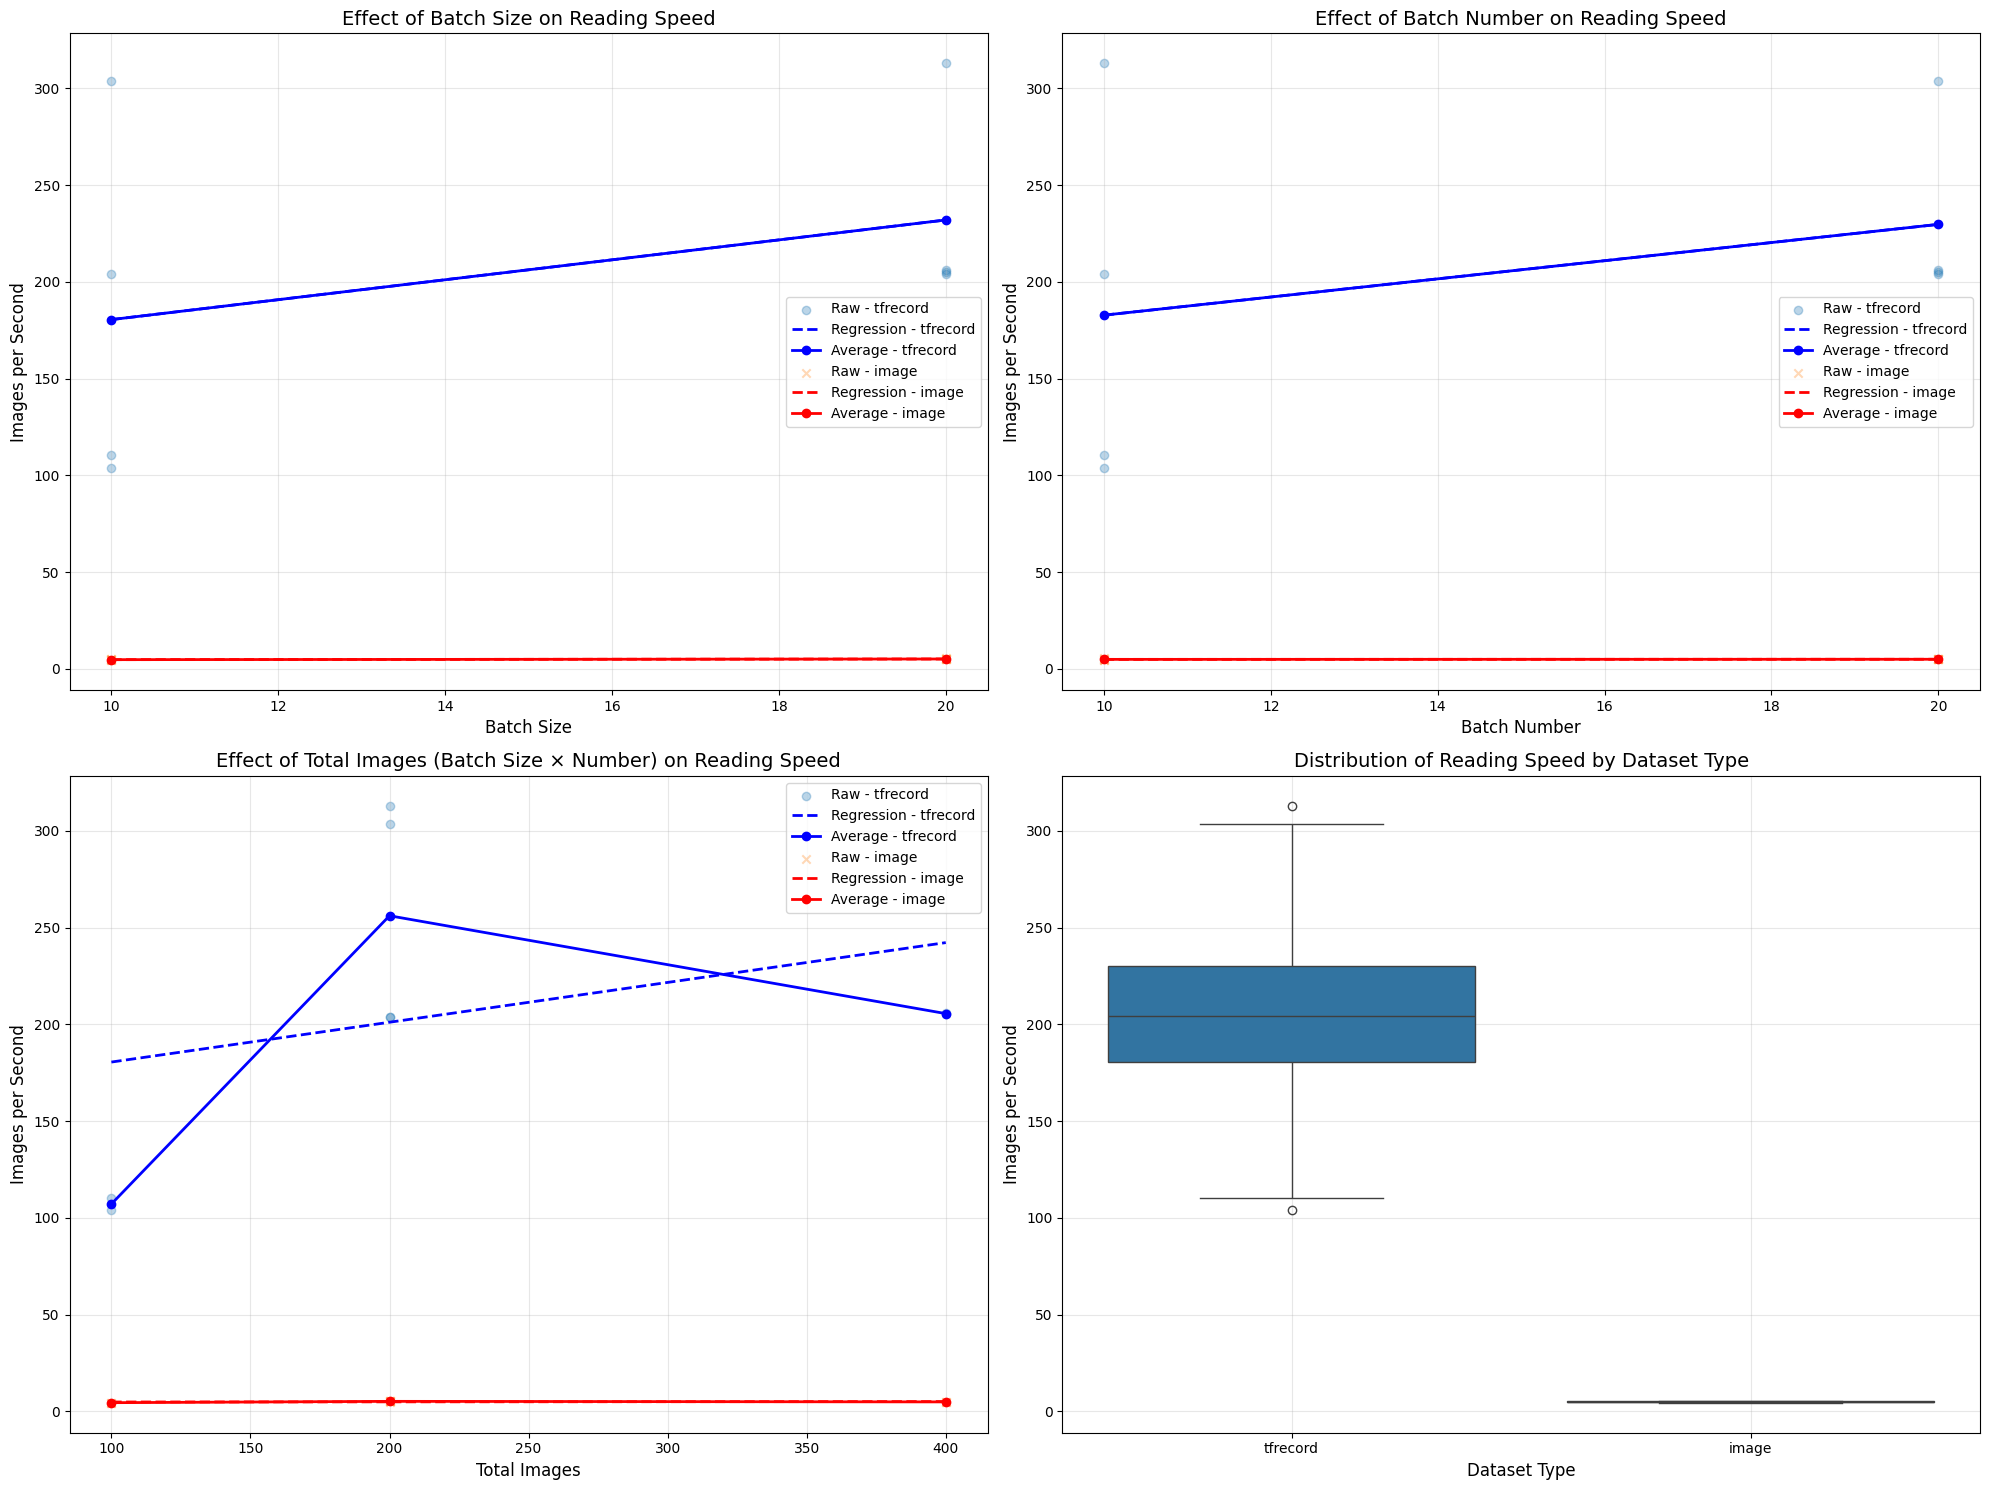

Analysis complete. Visualization saved as 'speed_test_analysis.png'


In [ ]:
### Performance Analysis and Visualization ###
# Assistance for Code Refactor/Reorganization and explicit print functions from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pandas as pd
import seaborn as sns

# Load the cloud results
cloud_results_path = "/content/speed_test_cloud_250429-2305.pickle"
with open(cloud_results_path, "rb") as f:
    results = pickle.load(f)

# Converting to DataFrame for analysis
print("Converting results to DataFrame...")
data = []
for params, speed in results['all_results']:
    dataset_type, batch_size, batch_number, repetition = params
    data.append({
        'dataset_type': dataset_type,
        'batch_size': batch_size,
        'batch_number': batch_number,
        'repetition': repetition,
        'images_per_second': speed,
        'total_images': batch_size * batch_number
    })

df = pd.DataFrame(data)
print(f"Created DataFrame with {len(df)} rows")

# Displaying a sample of the data
print("\nSample of the collected data:")
print(df)

# Creating comprehensive summary statistics
print("\n1. Summary Statistics by Dataset Type")
print("====================================")
ds_type_stats = df.groupby('dataset_type')['images_per_second'].describe()
print(ds_type_stats)

print("\n2. Summary Statistics by Batch Size")
print("=================================")
batch_size_stats = df.groupby('batch_size')['images_per_second'].describe()
print(batch_size_stats)

print("\n3. Summary Statistics by Batch Number")
print("===================================")
batch_number_stats = df.groupby('batch_number')['images_per_second'].describe()
print(batch_number_stats)

print("\n4. Summary Statistics by Total Images")
print("===================================")
total_images_stats = df.groupby('total_images')['images_per_second'].describe()
print(total_images_stats)

# Linear regression for each parameter, separated by dataset type
print("\n5. Linear Regression Analysis")
print("===========================")

# Spliting data by dataset type
tfrecord_df = df[df['dataset_type'] == 'tfrecord']
image_df = df[df['dataset_type'] == 'image']

# Defining function to perform regression and return results
def perform_regression(df, x_col, y_col='images_per_second', dataset_type=None):
    X = df[x_col].values.reshape(-1, 1)
    y = df[y_col].values

    model = LinearRegression()
    model.fit(X, y)

    r_squared = model.score(X, y)
    coefficient = model.coef_[0]
    intercept = model.intercept_

    print(f"Regression for {x_col} {'(' + dataset_type + ')' if dataset_type else ''}:")
    print(f"  Coefficient: {coefficient:.6f}")
    print(f"  Intercept: {intercept:.6f}")
    print(f"  R-squared: {r_squared:.6f}")

    return model, r_squared, coefficient, intercept

# Performing regression for each parameter and dataset type
regression_results = {}

# Batch Size regression
print("\nBatch Size Regression:")
for dtype, df_subset in [('tfrecord', tfrecord_df), ('image', image_df)]:
    regression_results[f'batch_size_{dtype}'] = perform_regression(df_subset, 'batch_size', dataset_type=dtype)

# Batch Number regression
print("\nBatch Number Regression:")
for dtype, df_subset in [('tfrecord', tfrecord_df), ('image', image_df)]:
    regression_results[f'batch_number_{dtype}'] = perform_regression(df_subset, 'batch_number', dataset_type=dtype)

# Total Images regression
print("\nTotal Images Regression:")
for dtype, df_subset in [('tfrecord', tfrecord_df), ('image', image_df)]:
    regression_results[f'total_images_{dtype}'] = perform_regression(df_subset, 'total_images', dataset_type=dtype)

# Creating summary table of regression results
summary_table = pd.DataFrame(columns=['Parameter', 'Dataset Type', 'Coefficient', 'Intercept', 'R²'])

row_idx = 0
for param in ['batch_size', 'batch_number', 'total_images']:
    for dtype in ['tfrecord', 'image']:
        _, r_squared, coef, intercept = regression_results[f'{param}_{dtype}']
        summary_table.loc[row_idx] = [param, dtype, coef, intercept, r_squared]
        row_idx += 1

print("\n6. Linear Regression Summary Table")
print("================================")
print(summary_table)

# Calculating performance ratio between TFRecord and Image formats
tfrecord_avg = df[df['dataset_type'] == 'tfrecord']['images_per_second'].mean()
image_avg = df[df['dataset_type'] == 'image']['images_per_second'].mean()
improvement_ratio = tfrecord_avg / image_avg if image_avg > 0 else float('inf')

print(f"\n7. Performance Comparison")
print("======================")
print(f"Average TFRecord speed: {tfrecord_avg:.2f} images/sec")
print(f"Average raw image speed: {image_avg:.2f} images/sec")
print(f"Speed improvement ratio (TFRecord / raw): {improvement_ratio:.2f}x")

# Creating visualizations
print("\n8. Creating Visualizations...")
plt.figure(figsize=(20, 15))

# Plot 1: Batch Size vs. Images/sec
plt.subplot(2, 2, 1)
for dtype, marker, color in [('tfrecord', 'o', 'blue'), ('image', 'x', 'red')]:
    df_subset = df[df['dataset_type'] == dtype]
    plt.scatter(df_subset['batch_size'], df_subset['images_per_second'], marker=marker, alpha=0.3, label=f'Raw - {dtype}')

    # Adding regression line
    model = regression_results[f'batch_size_{dtype}'][0]
    x_range = np.array([min(df_subset['batch_size']), max(df_subset['batch_size'])]).reshape(-1, 1)
    plt.plot(x_range, model.predict(x_range), '--', color=color, linewidth=2, label=f'Regression - {dtype}')

    # Adding average points
    avg_data = df_subset.groupby('batch_size')['images_per_second'].mean().reset_index()
    plt.plot(avg_data['batch_size'], avg_data['images_per_second'], marker='o', linestyle='-',
             color=color, linewidth=2, label=f'Average - {dtype}')

plt.title('Effect of Batch Size on Reading Speed', fontsize=14)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Images per Second', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Batch Number vs. Images/sec
plt.subplot(2, 2, 2)
for dtype, marker, color in [('tfrecord', 'o', 'blue'), ('image', 'x', 'red')]:
    df_subset = df[df['dataset_type'] == dtype]
    plt.scatter(df_subset['batch_number'], df_subset['images_per_second'], marker=marker, alpha=0.3, label=f'Raw - {dtype}')

    # Adding regression line
    model = regression_results[f'batch_number_{dtype}'][0]
    x_range = np.array([min(df_subset['batch_number']), max(df_subset['batch_number'])]).reshape(-1, 1)
    plt.plot(x_range, model.predict(x_range), '--', color=color, linewidth=2, label=f'Regression - {dtype}')

    # Adding average points
    avg_data = df_subset.groupby('batch_number')['images_per_second'].mean().reset_index()
    plt.plot(avg_data['batch_number'], avg_data['images_per_second'], marker='o', linestyle='-',
             color=color, linewidth=2, label=f'Average - {dtype}')

plt.title('Effect of Batch Number on Reading Speed', fontsize=14)
plt.xlabel('Batch Number', fontsize=12)
plt.ylabel('Images per Second', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 3: Total Images vs. Images/sec
plt.subplot(2, 2, 3)
for dtype, marker, color in [('tfrecord', 'o', 'blue'), ('image', 'x', 'red')]:
    df_subset = df[df['dataset_type'] == dtype]
    plt.scatter(df_subset['total_images'], df_subset['images_per_second'], marker=marker, alpha=0.3, label=f'Raw - {dtype}')

    # Adding regression line
    model = regression_results[f'total_images_{dtype}'][0]
    x_range = np.array([min(df_subset['total_images']), max(df_subset['total_images'])]).reshape(-1, 1)
    plt.plot(x_range, model.predict(x_range), '--', color=color, linewidth=2, label=f'Regression - {dtype}')

    # Adding average points
    avg_data = df_subset.groupby('total_images')['images_per_second'].mean().reset_index()
    plt.plot(avg_data['total_images'], avg_data['images_per_second'], marker='o', linestyle='-',
             color=color, linewidth=2, label=f'Average - {dtype}')

plt.title('Effect of Total Images (Batch Size × Number) on Reading Speed', fontsize=14)
plt.xlabel('Total Images', fontsize=12)
plt.ylabel('Images per Second', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 4: Box plots comparing formats
plt.subplot(2, 2, 4)
sns.boxplot(x='dataset_type', y='images_per_second', data=df)
plt.title('Distribution of Reading Speed by Dataset Type', fontsize=14)
plt.xlabel('Dataset Type', fontsize=12)
plt.ylabel('Images per Second', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('speed_test_analysis.png', dpi=300)
plt.show()

print("Analysis complete. Visualization saved as 'speed_test_analysis.png'")

# Section 3. Theoretical discussion

# Cloud Configuration Optimization

## Applying Research to Practice

This section explores how our performance findings relate to cloud configuration optimization research, particularly:
- Alipourfard, O., Liu, H. H., Chen, J., Venkataraman, S., Yu, M., & Zhang, M. (2017). [Cherrypick: Adaptively unearthing the best cloud configurations for big data analytics.](https://people.irisa.fr/Davide.Frey/wp-content/uploads/2018/02/cherrypick.pdf). In USENIX NSDI 17 (pp. 469-482).

The CherryPick approach demonstrates techniques for automatically selecting optimal or near-optimal cloud configurations for specific workloads.

### Implementation Context

Based on our performance benchmarking results, we'll analyze how the concepts from CherryPick can be applied to image processing workloads. This includes examining which performance metrics most strongly correlate with overall processing efficiency and how these insights can guide configuration selection.

### Strategic Applications

The final section provides concrete strategies for optimizing cloud configurations across different processing scenarios:
- Batch processing of large image datasets
- Stream processing for real-time applications
- Cost-performance tradeoff analyses for different workload patterns

These strategies connect our empirical findings with practical deployment recommendations.

## Resource Management

When you've completed your experiments, it's good practice to clean up your cloud resources to avoid unnecessary charges. The following commands will empty and delete your storage buckets:

In [ ]:
!gsutil -m rm -r $BUCKET/* # Empty your bucket
!gsutil rb $BUCKET # delete the bucket